# SciFact Reranker Benchmark on Colab

This notebook benchmarks a fixed `embeddinggemma_fact_check` bi-encoder retriever plus a diverse set of rerankers on `mteb/scifact`.

It evaluates `query -> abstract` retrieval over the SciFact test set: `300` unique queries over `5,183` abstracts.


## Experiment setup

This experiment fixes the first-stage retriever to `embeddinggemma_fact_check`, then reranks the bi-encoder candidates at `K=50` and `K=100`.

Reranker shortlist:

- `cross-encoder/ms-marco-MiniLM-L12-v2`
- `Alibaba-NLP/gte-reranker-modernbert-base`
- `jinaai/jina-reranker-v2-base-multilingual`
- `BAAI/bge-reranker-v2-m3`
- `Qwen/Qwen3-Reranker-0.6B`

The report compares retriever-only against reranked results using `nDCG@10`, `MRR@10`, `MAP@10`, stage-1 candidate recall, reranker latency, and total query latency.


In [1]:
# Optional: clone the repo only if you want a fresh remote checkout.
# Do not run this if you already uploaded or mounted an updated local copy.
!git clone https://github.com/Wasiq-Malik/ScholarRAG.git /content/ScholarRAG


fatal: destination path '/content/ScholarRAG' already exists and is not an empty directory.


In [2]:
%cd /content/ScholarRAG

!python -m pip install -U pip
!pip install -e .


/content/ScholarRAG
Obtaining file:///content/ScholarRAG
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scholarrag (pyproject.toml) ... done
  Created wheel for scholarrag: filename=scholarrag-0.1.0-0.editable-py3-none-any.whl size=6955 sha256=2acfbb25b57b472ea548ce3ab5fdd05f91c1ceef013944407067d5802fe87006
  Stored in directory: /tmp/pip-ephem-wheel-cache-qz5qsmvl/wheels/0a/89/0c/d5413d54f0d9857abad3277dd48a8e9f3f1a399dd033320dd6
Successfully built scholarrag
  Attempting uninstall: scholarrag
    Found existing installation: scholarrag 0.1.0
    Uninstalling scholarrag-0.1.0:
      Successfully uninstalled scholarrag-0.1.0


In [ ]:
!nvidia-smi || true
!pkill -9 7831 


Sun May 10 18:41:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             30W /   70W |   14893MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from datetime import datetime
from pathlib import Path
import json
import os

RUN_NAME = f"colab_scifact_rerank_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = Path("benchmarks/scifact/results") / RUN_NAME

# Set this when you want to resume fusion/report work from an existing reranker run.
SOURCE_RERANKER_RUN_DIR = Path('/content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744')  # e.g. Path("benchmarks/scifact/results/colab_scifact_rerank_...")

# Optional: paste a Hugging Face token for gated models in this session only.
HF_TOKEN = os.environ.get("HF_TOKEN", "")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
else:
    print("HF_TOKEN is not set. embeddinggemma-based retrieval will fail until you provide it.")

RETRIEVER_MODEL = "embeddinggemma_fact_check"
RERANKERS = [
    "msmarco_minilm_l12_v2",
    "gte_reranker_modernbert_base",
    "jina_reranker_v2_base_multilingual",
    "bge_reranker_v2_m3",
    "qwen3_reranker_0_6b",
]
CANDIDATE_KS = [50, 100]
SPLIT = "test"
DOCUMENT_MODE = "abstract"
DEVICE = "cuda"
DTYPE = "auto"
MAX_QUERIES = None

GPU_PRESETS = {
    "l4_default": {
        "msmarco_minilm_l12_v2": 64,
        "gte_reranker_modernbert_base": 32,
        "jina_reranker_v2_base_multilingual": 16,
        "bge_reranker_v2_m3": 16,
        "qwen3_reranker_0_6b": 8,
    },
    "l4_conservative": {
        "msmarco_minilm_l12_v2": 32,
        "gte_reranker_modernbert_base": 16,
        "jina_reranker_v2_base_multilingual": 8,
        "bge_reranker_v2_m3": 8,
        "qwen3_reranker_0_6b": 4,
    },
}

GPU_PRESET = "l4_default"
RERANKER_BATCH_OVERRIDES = dict(GPU_PRESETS[GPU_PRESET])

print(json.dumps({
    "output_dir": str(OUTPUT_DIR),
    "retriever_model": RETRIEVER_MODEL,
    "source_reranker_run_dir": str(SOURCE_RERANKER_RUN_DIR) if SOURCE_RERANKER_RUN_DIR else None,
    "rerankers": RERANKERS,
    "candidate_ks": CANDIDATE_KS,
    "split": SPLIT,
    "document_mode": DOCUMENT_MODE,
    "device": DEVICE,
    "dtype": DTYPE,
    "gpu_preset": GPU_PRESET,
    "reranker_batch_overrides": RERANKER_BATCH_OVERRIDES,
    "hf_token_set": bool(os.environ.get("HF_TOKEN")),
}, indent=2))



{
  "output_dir": "benchmarks/scifact/results/colab_scifact_rerank_20260510_185834",
  "retriever_model": "embeddinggemma_fact_check",
  "source_reranker_run_dir": "/content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744",
  "rerankers": [
    "msmarco_minilm_l12_v2",
    "gte_reranker_modernbert_base",
    "jina_reranker_v2_base_multilingual",
    "bge_reranker_v2_m3",
    "qwen3_reranker_0_6b"
  ],
  "candidate_ks": [
    50,
    100
  ],
  "split": "test",
  "document_mode": "abstract",
  "device": "cuda",
  "dtype": "auto",
  "gpu_preset": "l4_default",
  "reranker_batch_overrides": {
    "msmarco_minilm_l12_v2": 64,
    "gte_reranker_modernbert_base": 32,
    "jina_reranker_v2_base_multilingual": 16,
    "bge_reranker_v2_m3": 16,
    "qwen3_reranker_0_6b": 8
  },
  "hf_token_set": true
}


In [8]:
from benchmarks.scifact.models import available_model_keys
from benchmarks.scifact.reranker_models import available_reranker_keys

retriever_models = available_model_keys()
reranker_models = available_reranker_keys()
print("Retriever models:", retriever_models)
print("Reranker models:", reranker_models)
assert RETRIEVER_MODEL in retriever_models
missing = sorted(set(RERANKERS) - set(reranker_models))
if missing:
    raise ValueError(f"Notebook reranker list is not supported by the checked-out code: {missing}")


Retriever models: ['bge_en_icl_plain', 'bge_en_icl_examples', 'qwen3_0_6b', 'qwen3_4b', 'qwen3_8b', 'harrier_0_6b', 'embeddinggemma_300m', 'embeddinggemma_fact_check', 'embeddinggemma_qa', 'specter2']
Reranker models: ['msmarco_minilm_l12_v2', 'gte_reranker_modernbert_base', 'jina_reranker_v2_base_multilingual', 'bge_reranker_v2_m3', 'qwen3_reranker_0_6b']


## Preset guidance

- Start with `l4_default`.
- `qwen3_reranker_0_6b` and `jina_reranker_v2_base_multilingual` are the first rerankers to reduce if memory is tight.
- Candidate `K=100` is the main setting to test because your current retriever already reaches `Recall@100 = 0.9833`.
- `K=50` is the latency/quality tradeoff check.


In [9]:
import json
import os
import shlex
import signal
import subprocess
import sys
from pathlib import Path


def run_one_reranker(reranker_key: str) -> dict:
    model_dir = OUTPUT_DIR / reranker_key
    model_dir.mkdir(parents=True, exist_ok=True)
    log_path = model_dir / "run.log"

    cmd = [
        sys.executable,
        "benchmarks/scifact/run_reranker_benchmark.py",
        "--retriever-model", RETRIEVER_MODEL,
        "--split", SPLIT,
        "--document-mode", DOCUMENT_MODE,
        "--device", DEVICE,
        "--dtype", DTYPE,
        "--output-dir", str(model_dir),
        "--rerankers", reranker_key,
        "--candidate-ks", *[str(k) for k in CANDIDATE_KS],
    ]

    if MAX_QUERIES is not None:
        cmd += ["--max-queries", str(MAX_QUERIES)]

    batch_size = RERANKER_BATCH_OVERRIDES.get(reranker_key)
    if batch_size is not None:
        cmd += ["--reranker-batch-size", str(batch_size)]

    env = dict(os.environ)
    env["PYTHONUNBUFFERED"] = "1"

    print(f"=== Running {reranker_key} ===")
    print("Command:")
    print(" ".join(shlex.quote(part) for part in cmd))
    print(f"Log file: {log_path}")
    print(f"Configured batch size: {batch_size}")

    with log_path.open("w") as log_handle:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=env,
        )
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
            log_handle.write(line)
        returncode = process.wait()

    result = {
        "reranker": reranker_key,
        "batch_size": batch_size,
        "returncode": returncode,
        "status": "completed" if returncode == 0 else "failed",
        "log_path": str(log_path),
        "output_dir": str(model_dir),
    }
    if returncode == -signal.SIGKILL:
        result["failure_reason"] = "likely_oom_or_os_kill"
    elif returncode != 0:
        result["failure_reason"] = f"nonzero_exit_{returncode}"

    status_path = model_dir / "notebook_status.json"
    status_path.write_text(json.dumps(result, indent=2))
    return result

all_results = []
for reranker_key in RERANKERS:
    all_results.append(run_one_reranker(reranker_key))

aggregate_status_path = OUTPUT_DIR / "notebook_status.json"
aggregate_status_path.parent.mkdir(parents=True, exist_ok=True)
aggregate_status_path.write_text(json.dumps(all_results, indent=2))
all_results


=== Running msmarco_minilm_l12_v2 ===
Command:
/usr/bin/python3 benchmarks/scifact/run_reranker_benchmark.py --retriever-model embeddinggemma_fact_check --split test --document-mode abstract --device cuda --dtype auto --output-dir benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/msmarco_minilm_l12_v2 --rerankers msmarco_minilm_l12_v2 --candidate-ks 50 100 --reranker-batch-size 64
Log file: benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/msmarco_minilm_l12_v2/run.log
Configured batch size: 64

Generating corpus split: 100%|██████████| 5183/5183 [00:00<00:00, 73061.97 examples/s]

Generating queries split: 100%|██████████| 1109/1109 [00:00<00:00, 469420.04 examples/s]

Generating train split: 100%|██████████| 919/919 [00:00<00:00, 59803.35 examples/s]

Generating test split: 100%|██████████| 339/339 [00:00<00:00, 189456.24 examples/s]
2026-04-29 01:08:26.613972: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly differ

[{'reranker': 'msmarco_minilm_l12_v2',
  'batch_size': 64,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/msmarco_minilm_l12_v2/run.log',
  'output_dir': 'benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/msmarco_minilm_l12_v2'},
 {'reranker': 'gte_reranker_modernbert_base',
  'batch_size': 32,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/gte_reranker_modernbert_base/run.log',
  'output_dir': 'benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/gte_reranker_modernbert_base'},
 {'reranker': 'jina_reranker_v2_base_multilingual',
  'batch_size': 16,
  'returncode': 0,
  'status': 'completed',
  'log_path': 'benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/jina_reranker_v2_base_multilingual/run.log',
  'output_dir': 'benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/jina_reranker_v2_b

In [10]:
import json
import pandas as pd
from benchmarks.scifact.generate_reranker_report import build_report

summary_rows = []
for result in all_results:
    model_dir = Path(result["output_dir"])
    summary_path = model_dir / "summary.csv"
    if summary_path.exists():
        frame = pd.read_csv(summary_path)
        if not frame.empty:
            summary_rows.append(frame)

if summary_rows:
    aggregate_summary = pd.concat(summary_rows, ignore_index=True)
    aggregate_summary = aggregate_summary.drop_duplicates(
        subset=["stage", "retriever_model", "reranker_model", "candidate_k"],
        keep="first",
    )
    aggregate_summary = aggregate_summary.sort_values(["ndcg_at_10", "avg_total_query_latency_ms"], ascending=[False, True])
    aggregate_summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
    (OUTPUT_DIR / "summary.json").write_text(aggregate_summary.to_json(orient="records", indent=2))

    aggregate_config = {
        "retriever_model": RETRIEVER_MODEL,
        "rerankers": RERANKERS,
        "candidate_ks": CANDIDATE_KS,
        "split": SPLIT,
        "document_mode": DOCUMENT_MODE,
    }
    (OUTPUT_DIR / "config.json").write_text(json.dumps(aggregate_config, indent=2))
    report_path = build_report(OUTPUT_DIR)
    print(f"Wrote aggregate report to {report_path}")
    aggregate_summary
else:
    print("No successful reranker runs produced a summary.csv file.")


Wrote aggregate report to benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/REPORT.md


In [11]:
from IPython.display import Markdown, display

report_path = OUTPUT_DIR / "REPORT.md"
if report_path.exists():
    display(Markdown(report_path.read_text()))
else:
    print("No aggregate report found yet.")


# SciFact Reranker Report

## Run configuration

- Retriever: `embeddinggemma_fact_check`
- Split: `test`
- Document mode: `abstract`
- Candidate Ks: `[50, 100]`
- Rerankers: `msmarco_minilm_l12_v2, gte_reranker_modernbert_base, jina_reranker_v2_base_multilingual, bge_reranker_v2_m3, qwen3_reranker_0_6b`

## Headline results

- Best `nDCG@10`: `embeddinggemma_fact_check` at `0.7890`
- Best `MAP@10`: `embeddinggemma_fact_check` at `0.7435`
- Lowest average total query latency: `embeddinggemma_fact_check` at `1.19 ms`

## Metrics table

| Label | Stage | Candidate K | Stage1 Recall@K | nDCG@10 | MRR@10 | MAP@10 | Recall@10 | Avg Rerank (ms) | Avg Total Query (ms) |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.19 |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.21 |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.22 |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.23 |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.23 |
| gte_reranker_modernbert_base@50 | reranked | 50 | 0.9650 | 0.7681 | 0.7282 | 0.7176 | 0.9086 | 406.68 | 407.92 |
| qwen3_reranker_0_6b@50 | reranked | 50 | 0.9650 | 0.7641 | 0.7280 | 0.7192 | 0.8920 | 1265.17 | 1266.40 |
| gte_reranker_modernbert_base@100 | reranked | 100 | 0.9833 | 0.7621 | 0.7219 | 0.7112 | 0.9052 | 794.48 | 795.71 |
| qwen3_reranker_0_6b@100 | reranked | 100 | 0.9833 | 0.7619 | 0.7265 | 0.7165 | 0.8902 | 2386.13 | 2387.35 |
| jina_reranker_v2_base_multilingual@50 | reranked | 50 | 0.9650 | 0.7589 | 0.7233 | 0.7149 | 0.8863 | 380.73 | 381.93 |
| jina_reranker_v2_base_multilingual@100 | reranked | 100 | 0.9833 | 0.7560 | 0.7238 | 0.7152 | 0.8713 | 748.56 | 749.77 |
| bge_reranker_v2_m3@50 | reranked | 50 | 0.9650 | 0.7304 | 0.6971 | 0.6834 | 0.8603 | 661.51 | 662.73 |
| bge_reranker_v2_m3@100 | reranked | 100 | 0.9833 | 0.7239 | 0.6939 | 0.6795 | 0.8447 | 1314.08 | 1315.30 |
| msmarco_minilm_l12_v2@50 | reranked | 50 | 0.9650 | 0.6951 | 0.6555 | 0.6441 | 0.8396 | 85.84 | 87.03 |
| msmarco_minilm_l12_v2@100 | reranked | 100 | 0.9833 | 0.6893 | 0.6509 | 0.6396 | 0.8296 | 174.34 | 175.53 |

## Plots

- `plots/ndcg_at_10.png`
- `plots/mrr_at_10.png`
- `plots/map_at_10.png`
- `plots/avg_total_query_latency_ms.png`
- `plots/ndcg_vs_total_query_latency.png`


benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/plots/ndcg_at_10.png


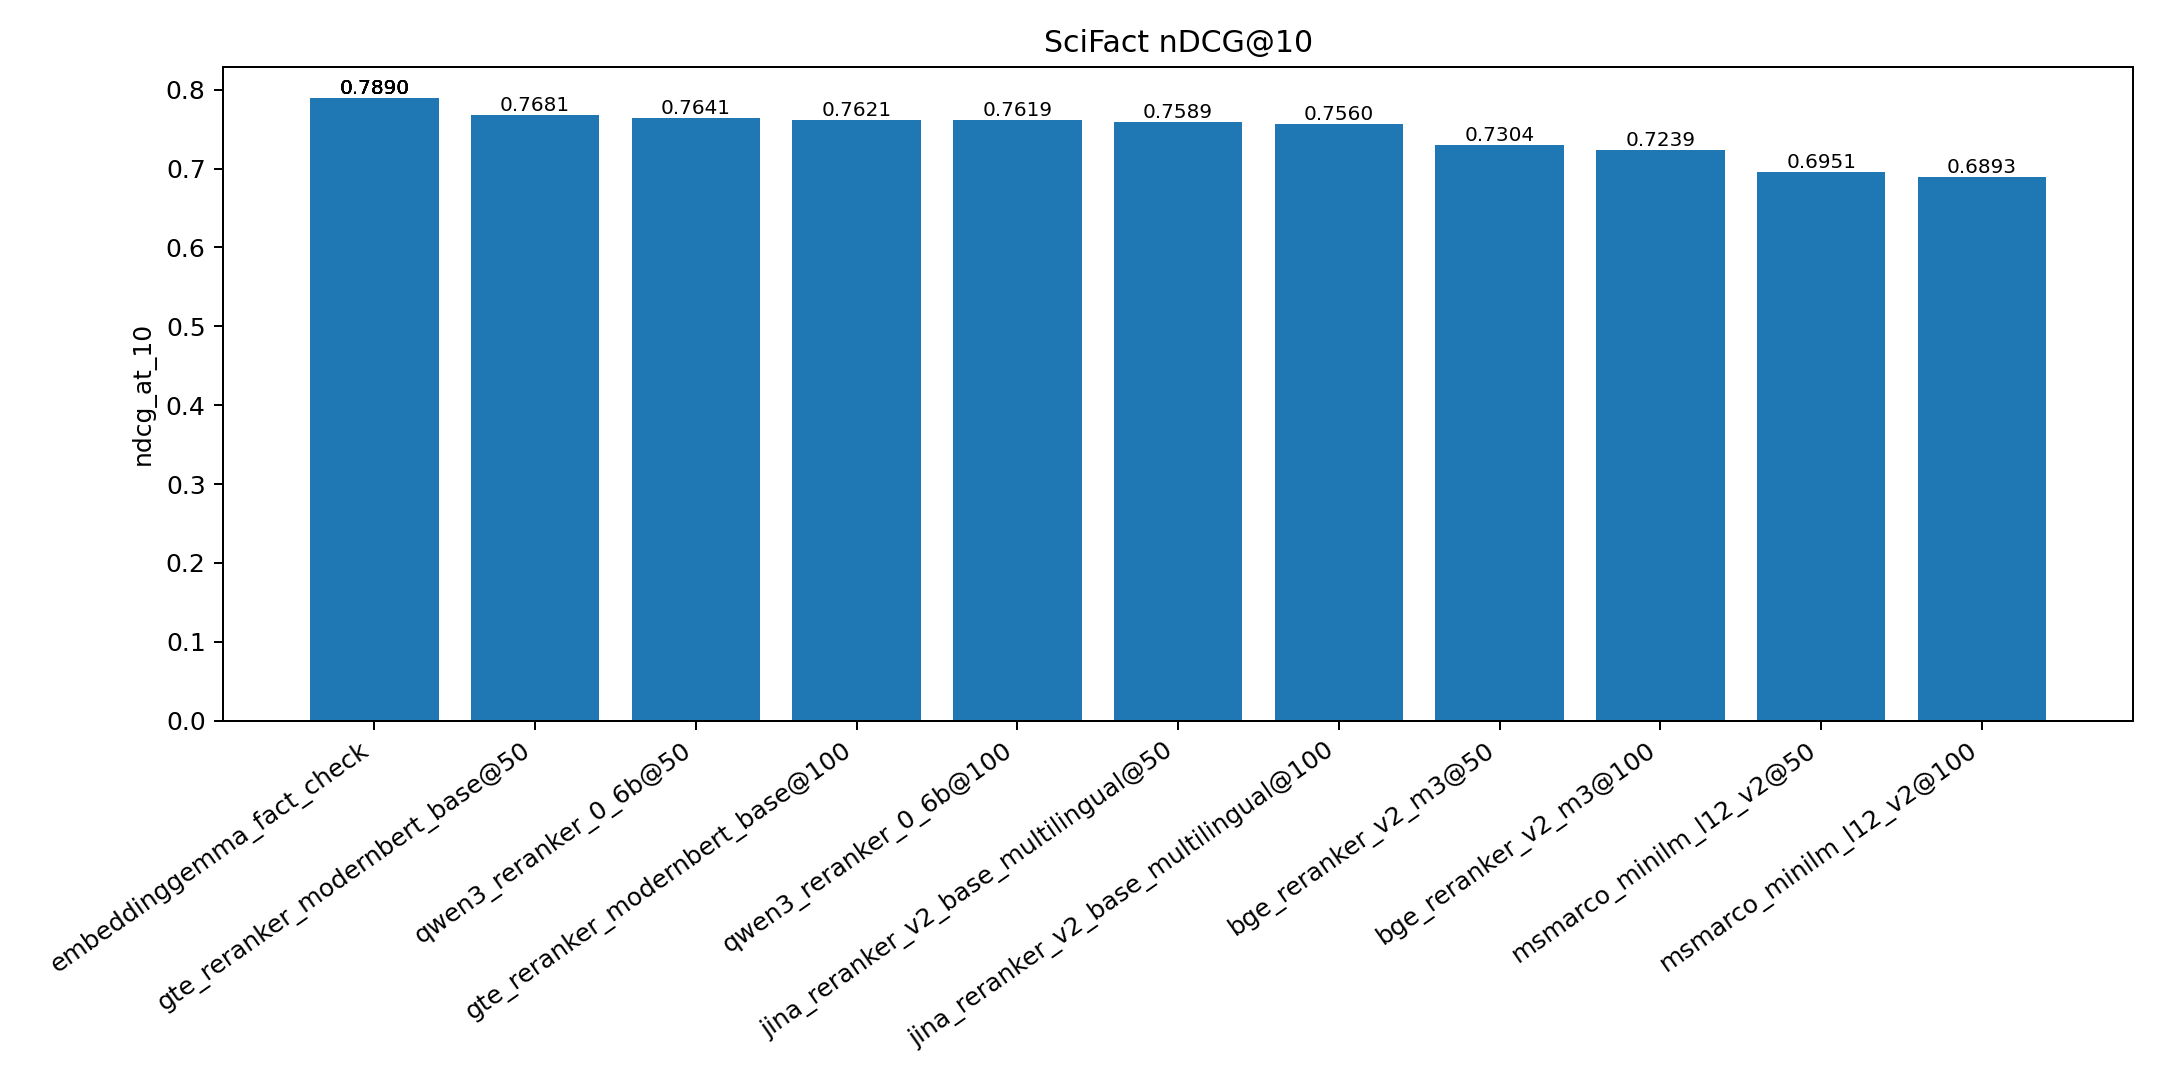

benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/plots/mrr_at_10.png


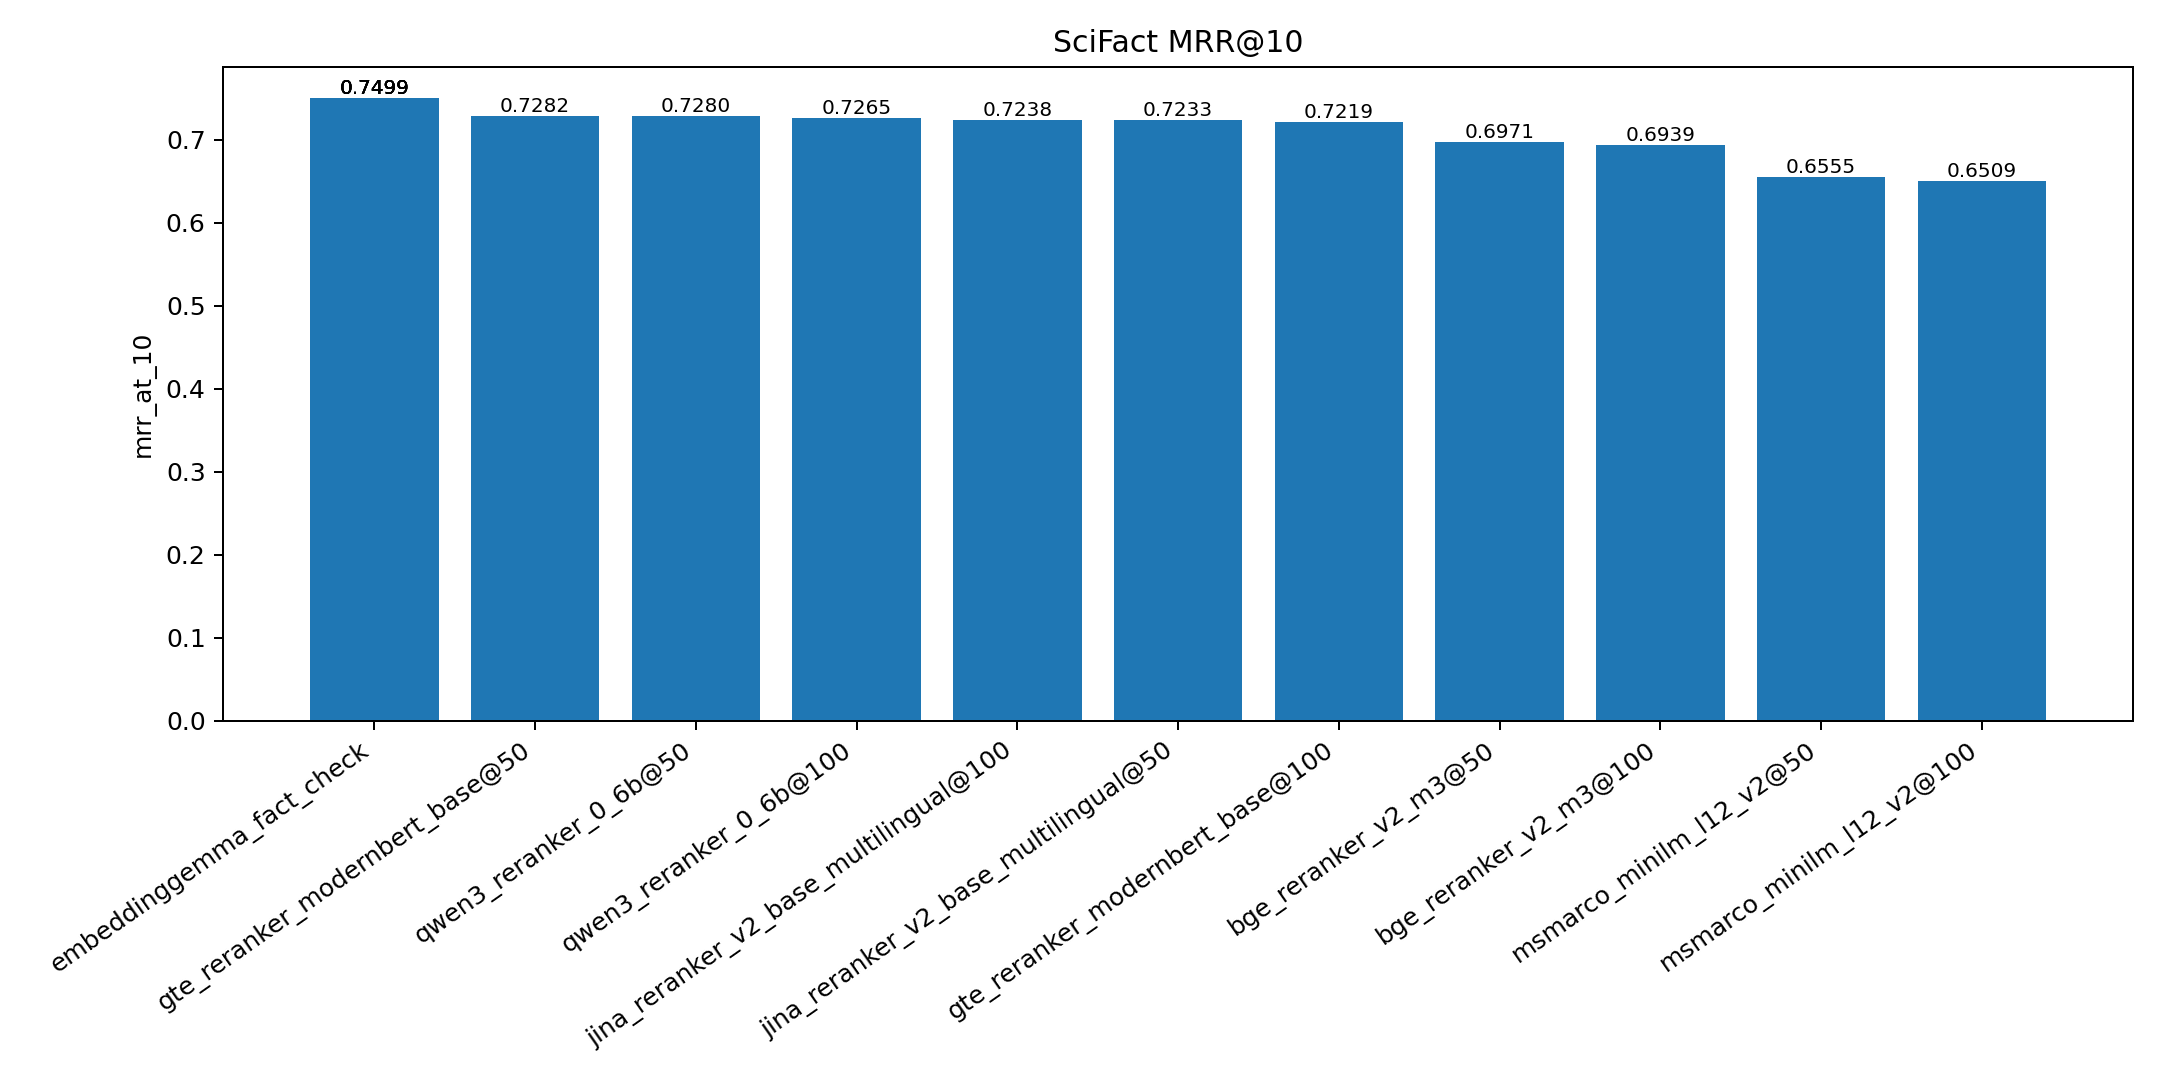

benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/plots/map_at_10.png


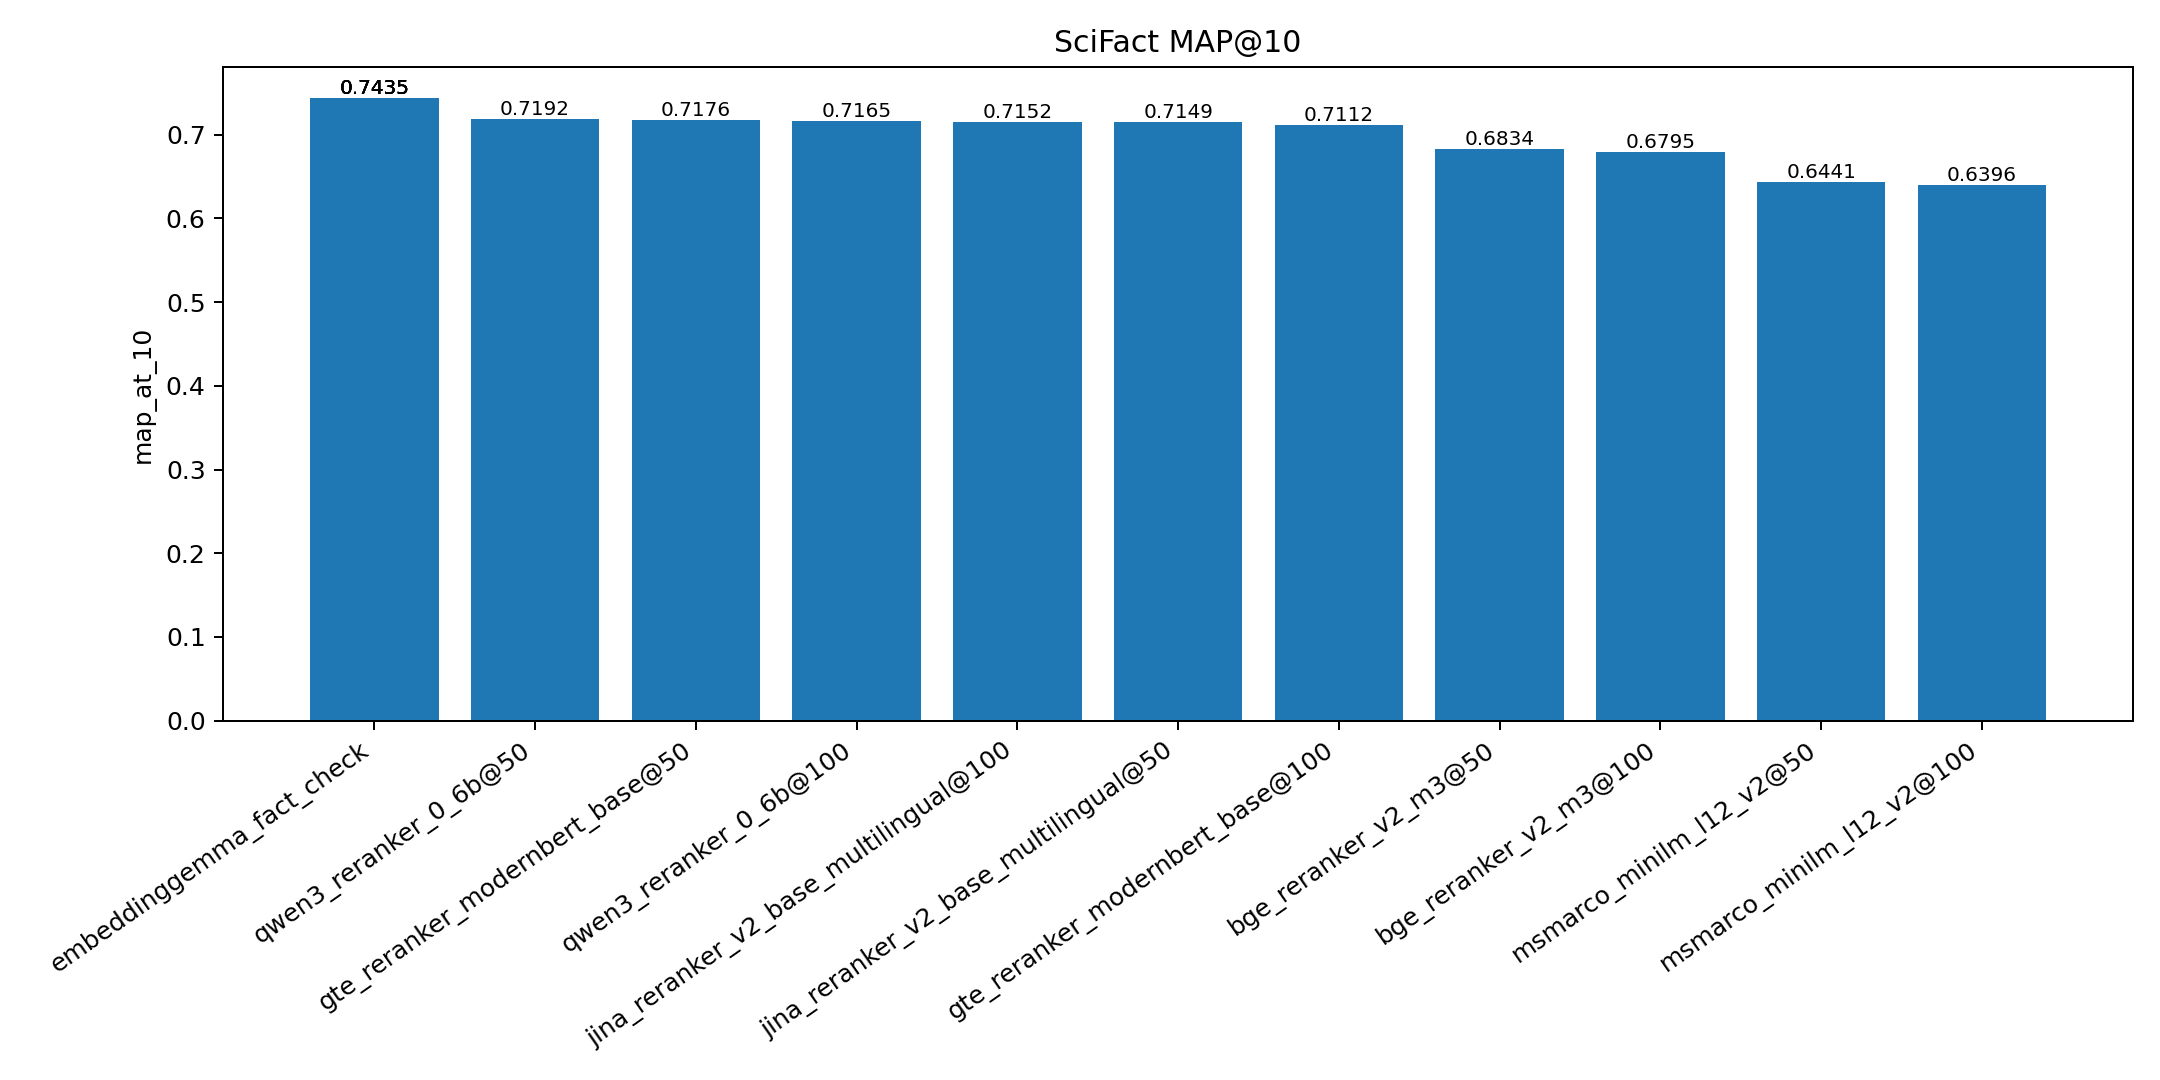

benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/plots/avg_total_query_latency_ms.png


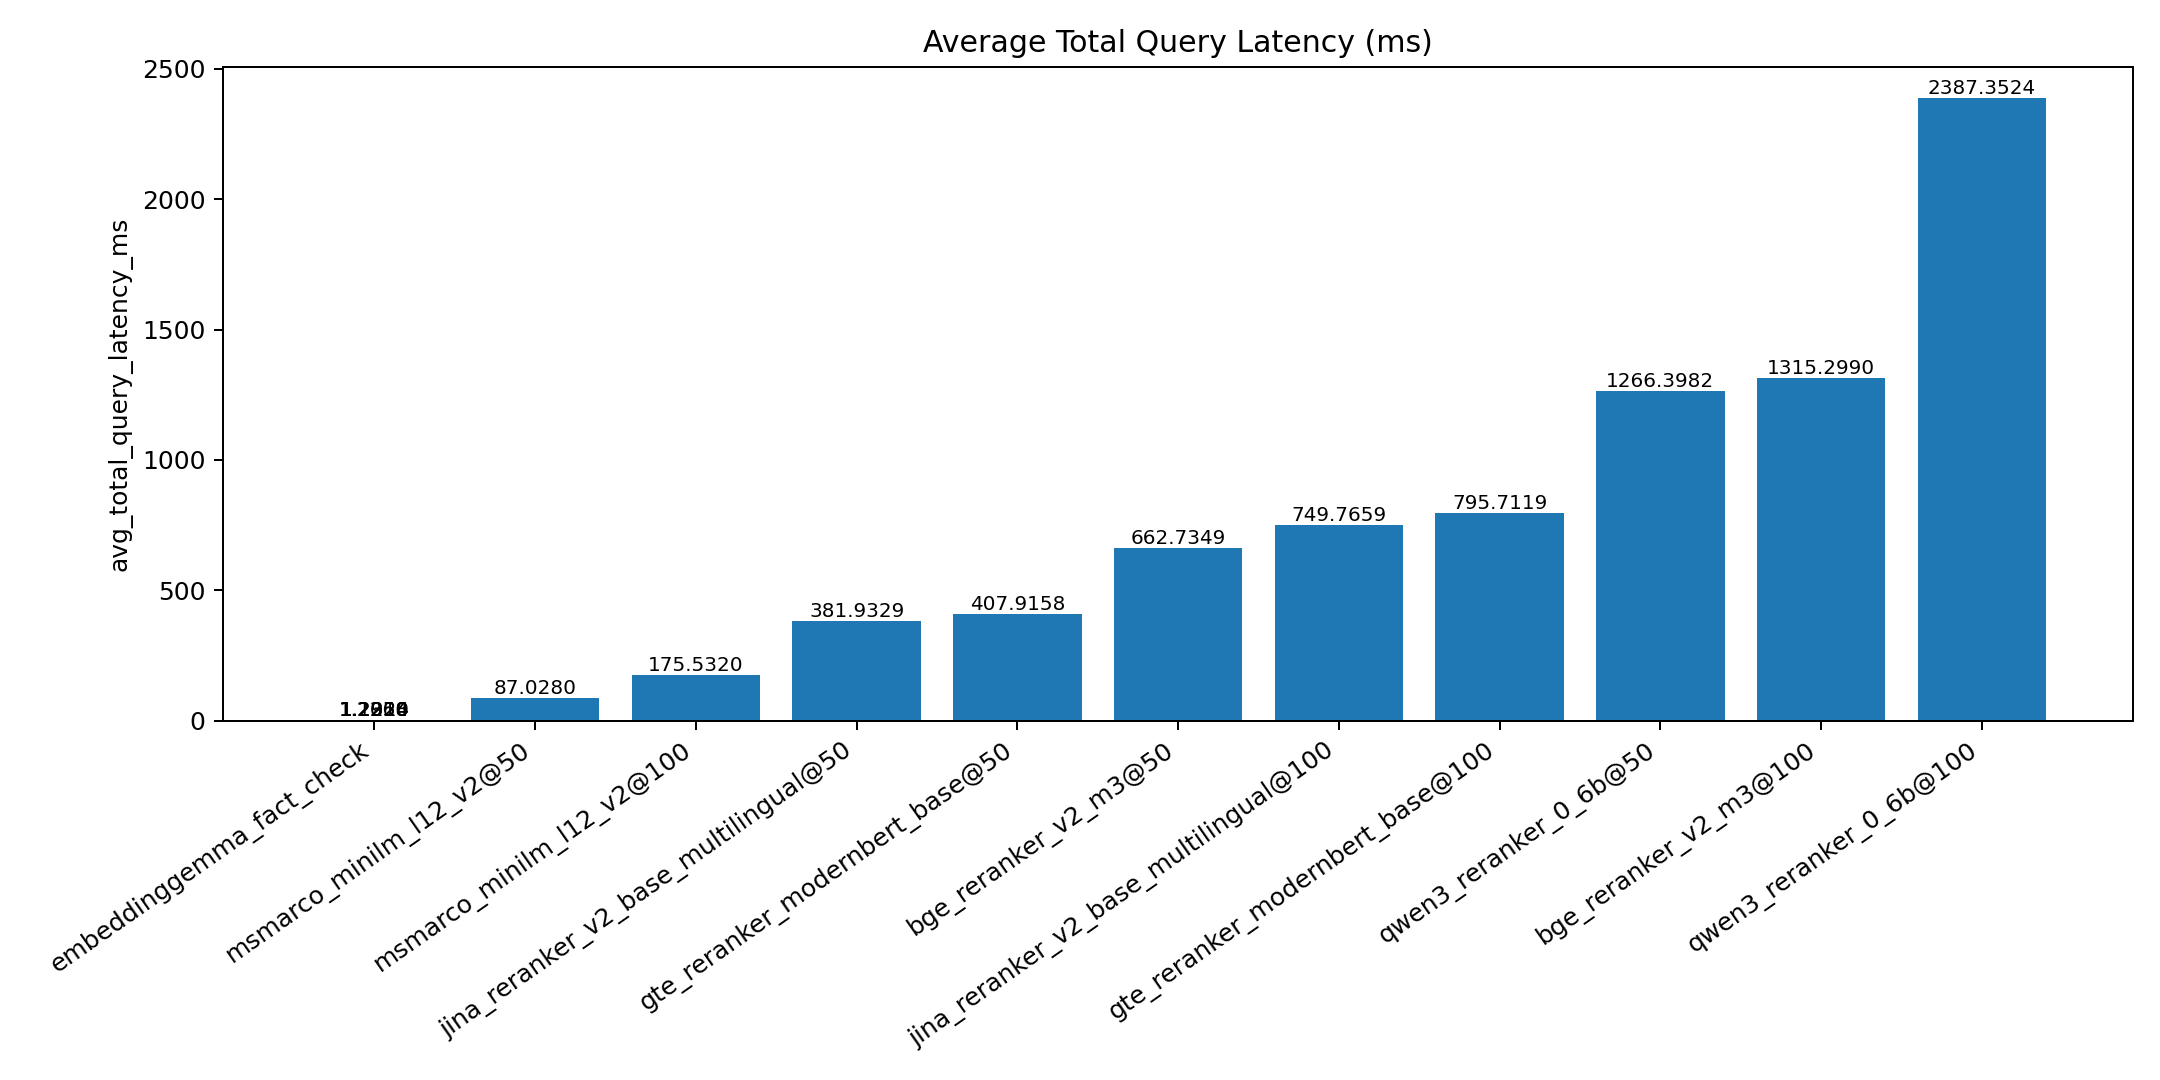

benchmarks/scifact/results/colab_scifact_rerank_20260429_010714/plots/ndcg_vs_total_query_latency.png


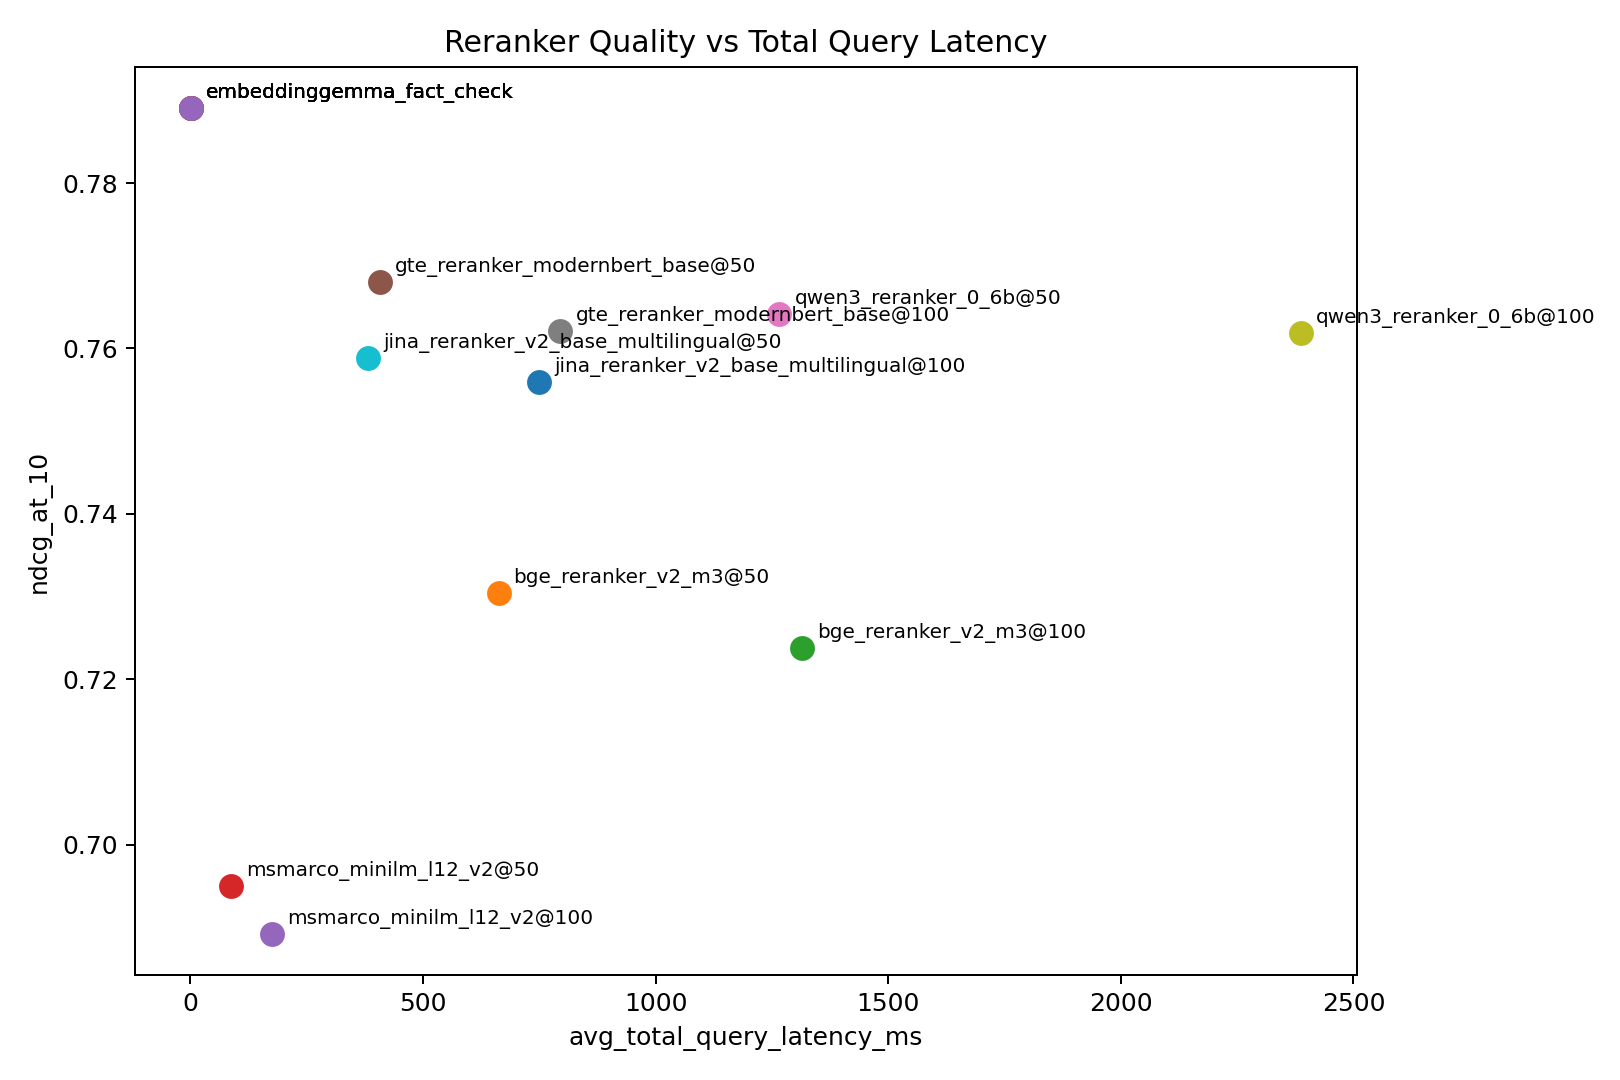

In [12]:
from IPython.display import Image, display

plots_dir = OUTPUT_DIR / "plots"
for name in [
    "ndcg_at_10.png",
    "mrr_at_10.png",
    "map_at_10.png",
    "avg_total_query_latency_ms.png",
    "ndcg_vs_total_query_latency.png",
]:
    path = plots_dir / name
    if path.exists():
        print(path)
        display(Image(filename=str(path)))


## Score Fusion Follow-up

The first reranker pass fully replaced the `embeddinggemma_fact_check` retrieval score with the reranker score. Since the retriever-only baseline stayed above every reranked result, the next experiment keeps the original run intact and tests a score-fusion variant instead of changing the reranker setup.

### What score fusion is

For each query and candidate abstract, we keep both signals:
- the first-stage `embeddinggemma_fact_check` retrieval score
- the second-stage reranker score

We normalize both score lists within each query's candidate set using min-max normalization, then blend them with a tunable mixing weight `alpha`.

### Fusion equation

`fused_score(q, d) = alpha * norm(retriever_score(q, d)) + (1 - alpha) * norm(reranker_score(q, d))`

where:
- `q` is the query
- `d` is a candidate abstract
- `norm(.)` is per-query min-max normalization over the candidate set
- `alpha in [0, 1]`

Interpretation:
- `alpha = 1.0` means retriever-only ordering
- `alpha = 0.0` means reranker-only ordering inside the candidate set
- intermediate `alpha` values preserve part of the fact-check-aware retriever signal while still letting the reranker reshuffle the list

### Why we are doing this

The first reranker experiment suggested that the generic rerankers were discarding useful information already captured by `embeddinggemma_fact_check`. Fusion tests a narrower hypothesis: the reranker may still contain useful local ranking information, but it should be combined with the retriever score instead of replacing it. If that hypothesis is correct, a blended score should beat both the retriever-only and reranker-only extremes.


In [33]:
import json
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd

from benchmarks.scifact.data import load_scifact
from benchmarks.scifact.generate_reranker_report import build_report
from benchmarks.scifact.metrics import score_ranked_lists, write_rankings_csv


ACTIVE_RERANKER_RUN_DIR = Path('/content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744')  # e.g. Path("benchmarks/scifact/results/colab_scifact_rerank_...")
FUSION_OUTPUT_DIR = ACTIVE_RERANKER_RUN_DIR.parent / f"{ACTIVE_RERANKER_RUN_DIR.name}_fusion"
FUSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FUSION_ALPHAS = [round(alpha, 2) for alpha in np.linspace(0.05, 0.95, 19)]


def minmax_normalize(values):
    array = np.asarray(values, dtype=float)
    lower = float(array.min())
    upper = float(array.max())
    if upper - lower < 1e-12:
        return np.ones_like(array, dtype=float)
    return (array - lower) / (upper - lower)


def parse_fusion_label(label):
    match = re.match(r"(?P<base>.+)_fusion_a(?P<alpha>\d+\.\d+)$", label)
    if match is None:
        raise ValueError(f"Unexpected fusion label: {label}")
    return match.group("base"), float(match.group("alpha"))


def recall_for_candidates(candidate_ids, relevant_docs):
    if not relevant_docs:
        return 0.0
    hits = sum(1 for corpus_id in candidate_ids if corpus_id in relevant_docs)
    return hits / len(relevant_docs)


def load_fusion_context():
    summary = pd.read_csv(ACTIVE_RERANKER_RUN_DIR / "summary.csv")
    reranked_rows = summary[summary["stage"] == "reranked"].copy()
    result_dirs = [ACTIVE_RERANKER_RUN_DIR / str(reranker_key) for reranker_key in reranked_rows["reranker_model"].drop_duplicates().tolist()]
    missing_result_dirs = [path for path in result_dirs if not path.exists()]
    if missing_result_dirs:
        raise FileNotFoundError(f"Missing reranker result directories under {ACTIVE_RERANKER_RUN_DIR}: {missing_result_dirs}")

    scifact_eval = load_scifact(
        split=SPLIT,
        document_mode=DOCUMENT_MODE,
        cache_dir=Path("data/hf_cache"),
        max_queries=MAX_QUERIES,
    )
    query_text_lookup = {str(query_id): text for query_id, text in zip(scifact_eval.query_ids, scifact_eval.query_texts, strict=True)}
    corpus_text_lookup = {str(corpus_id): text for corpus_id, text in zip(scifact_eval.corpus_ids, scifact_eval.corpus_texts, strict=True)}

    baseline_rankings_path = result_dirs[0] / "rankings" / f"{RETRIEVER_MODEL}.csv"
    baseline_rankings = pd.read_csv(baseline_rankings_path)
    baseline_rankings["query_id"] = baseline_rankings["query_id"].astype(str)
    baseline_rankings["corpus_id"] = baseline_rankings["corpus_id"].astype(str)
    query_ids = baseline_rankings["query_id"].drop_duplicates().tolist()
    positives_by_query = {}
    baseline_scores_by_query = {}
    candidate_ids_by_query = {int(k): {} for k in CANDIDATE_KS}
    stage1_recall_by_k = {int(k): [] for k in CANDIDATE_KS}

    for query_id, frame in baseline_rankings.groupby("query_id", sort=False):
        ordered = frame.sort_values("rank")
        positives = ordered.loc[ordered["relevance"] > 0, ["corpus_id", "relevance"]].copy()
        positives["corpus_id"] = positives["corpus_id"].astype(str)
        ordered["corpus_id"] = ordered["corpus_id"].astype(str)
        positives_by_query[str(query_id)] = dict(zip(positives["corpus_id"], positives["relevance"], strict=True))
        baseline_scores_by_query[str(query_id)] = dict(zip(ordered["corpus_id"], ordered["score"], strict=True))
        ranked_ids = ordered["corpus_id"].astype(str).tolist()
        query_id = str(query_id)
        for candidate_k in [int(k) for k in CANDIDATE_KS]:
            candidate_ids_by_query[candidate_k][query_id] = ranked_ids[:candidate_k]
            stage1_recall_by_k[candidate_k].append(recall_for_candidates(ranked_ids[:candidate_k], positives_by_query[query_id]))

    baseline_row = summary[summary["stage"] == "retriever_only"].sort_values("avg_total_query_latency_ms").iloc[0]
    return {
        "summary": summary,
        "reranked_rows": reranked_rows,
        "result_dirs": result_dirs,
        "query_ids": query_ids,
        "positives_by_query": positives_by_query,
        "baseline_scores_by_query": baseline_scores_by_query,
        "candidate_ids_by_query": candidate_ids_by_query,
        "stage1_recall_by_k": stage1_recall_by_k,
        "query_text_lookup": query_text_lookup,
        "corpus_text_lookup": corpus_text_lookup,
        "baseline_row": baseline_row,
    }


def load_score_lookup_from_rankings(rankings_path):
    rankings = pd.read_csv(rankings_path)
    rankings["query_id"] = rankings["query_id"].astype(str)
    rankings["corpus_id"] = rankings["corpus_id"].astype(str)
    score_lookup_by_query = {}
    for query_id, frame in rankings.groupby("query_id", sort=False):
        ordered = frame.sort_values("rank")
        ordered["corpus_id"] = ordered["corpus_id"].astype(str)
        score_lookup_by_query[str(query_id)] = dict(zip(ordered["corpus_id"], ordered["score"], strict=True))
    return score_lookup_by_query


def run_fusion_for_score_lookup(
    *,
    context,
    output_dir,
    reranker_label,
    reranker_model_id,
    reranker_family,
    reranker_batch_size,
    candidate_k,
    score_lookup_by_query,
    reranker_seconds,
    fusion_alphas,
    notes_prefix,
):
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "rankings").mkdir(parents=True, exist_ok=True)
    rows = []
    query_ids = context["query_ids"]
    positives_by_query = context["positives_by_query"]
    candidate_ids_by_query = context["candidate_ids_by_query"][int(candidate_k)]
    baseline_scores_by_query = context["baseline_scores_by_query"]
    baseline_row = context["baseline_row"]
    stage1_recall_at_k = float(np.mean(context["stage1_recall_by_k"][int(candidate_k)]))

    reranked_ids_by_query = {}
    reranked_scores_by_query = {}
    for query_id in query_ids:
        candidate_ids = candidate_ids_by_query[query_id]
        aligned_scores = [float(score_lookup_by_query[query_id][corpus_id]) for corpus_id in candidate_ids]
        order = np.argsort(-np.asarray(aligned_scores, dtype=float))
        reranked_ids_by_query[query_id] = [candidate_ids[index] for index in order]
        reranked_scores_by_query[query_id] = [float(aligned_scores[index]) for index in order]

    reranked_metrics = score_ranked_lists(
        query_ids=query_ids,
        ranked_corpus_ids_by_query=reranked_ids_by_query,
        positives_by_query=positives_by_query,
    )
    rows.append({
        "stage": "reranked",
        "retriever_model": RETRIEVER_MODEL,
        "reranker_model": reranker_label,
        "reranker_model_id": reranker_model_id,
        "reranker_family": reranker_family,
        "candidate_k": int(candidate_k),
        "stage1_recall_at_k": stage1_recall_at_k,
        "ndcg_at_10": reranked_metrics.ndcg_at_10,
        "mrr_at_10": reranked_metrics.mrr_at_10,
        "recall_at_10": reranked_metrics.recall_at_10,
        "recall_at_50": reranked_metrics.recall_at_50,
        "recall_at_100": reranked_metrics.recall_at_100,
        "map_at_10": reranked_metrics.map_at_10,
        "retriever_query_stage_seconds": float(baseline_row["retriever_query_stage_seconds"]),
        "avg_retriever_query_latency_ms": float(baseline_row["avg_retriever_query_latency_ms"]),
        "reranker_seconds": float(reranker_seconds),
        "avg_reranker_latency_ms": (float(reranker_seconds) / len(query_ids)) * 1000.0,
        "avg_total_query_latency_ms": float(baseline_row["avg_total_query_latency_ms"]) + (float(reranker_seconds) / len(query_ids)) * 1000.0,
        "reranker_batch_size": int(reranker_batch_size),
        "notes": notes_prefix,
    })
    write_rankings_csv(
        model_name=reranker_label,
        query_ids=query_ids,
        ranked_corpus_ids_by_query=reranked_ids_by_query,
        ranked_scores_by_query=reranked_scores_by_query,
        positives_by_query=positives_by_query,
        rankings_path=output_dir / "rankings" / f"{reranker_label}_k{int(candidate_k)}.csv",
    )

    for alpha in fusion_alphas:
        fused_ids_by_query = {}
        fused_scores_by_query = {}
        for query_id in query_ids:
            candidate_ids = candidate_ids_by_query[query_id]
            retriever_scores = [float(baseline_scores_by_query[query_id][corpus_id]) for corpus_id in candidate_ids]
            reranker_scores = [float(score_lookup_by_query[query_id][corpus_id]) for corpus_id in candidate_ids]
            retriever_norm = minmax_normalize(retriever_scores)
            reranker_norm = minmax_normalize(reranker_scores)
            fused_scores = alpha * retriever_norm + (1.0 - alpha) * reranker_norm
            order = np.argsort(-fused_scores)
            fused_ids_by_query[query_id] = [candidate_ids[index] for index in order]
            fused_scores_by_query[query_id] = [float(fused_scores[index]) for index in order]

        fused_metrics = score_ranked_lists(
            query_ids=query_ids,
            ranked_corpus_ids_by_query=fused_ids_by_query,
            positives_by_query=positives_by_query,
        )
        model_label = f"{reranker_label}_fusion_a{alpha:.2f}"
        rows.append({
            "stage": "score_fusion",
            "retriever_model": RETRIEVER_MODEL,
            "reranker_model": model_label,
            "reranker_model_id": reranker_model_id,
            "reranker_family": f"{reranker_family} + Gemma score fusion",
            "candidate_k": int(candidate_k),
            "stage1_recall_at_k": stage1_recall_at_k,
            "ndcg_at_10": fused_metrics.ndcg_at_10,
            "mrr_at_10": fused_metrics.mrr_at_10,
            "recall_at_10": fused_metrics.recall_at_10,
            "recall_at_50": fused_metrics.recall_at_50,
            "recall_at_100": fused_metrics.recall_at_100,
            "map_at_10": fused_metrics.map_at_10,
            "retriever_query_stage_seconds": float(baseline_row["retriever_query_stage_seconds"]),
            "avg_retriever_query_latency_ms": float(baseline_row["avg_retriever_query_latency_ms"]),
            "reranker_seconds": float(reranker_seconds),
            "avg_reranker_latency_ms": (float(reranker_seconds) / len(query_ids)) * 1000.0,
            "avg_total_query_latency_ms": float(baseline_row["avg_total_query_latency_ms"]) + (float(reranker_seconds) / len(query_ids)) * 1000.0,
            "reranker_batch_size": int(reranker_batch_size),
            "notes": f"alpha={alpha:.2f}; fused normalized retriever and reranker scores on the top-{int(candidate_k)} candidate set.",
        })
        write_rankings_csv(
            model_name=model_label,
            query_ids=query_ids,
            ranked_corpus_ids_by_query=fused_ids_by_query,
            ranked_scores_by_query=fused_scores_by_query,
            positives_by_query=positives_by_query,
            rankings_path=output_dir / "rankings" / f"{model_label}_k{int(candidate_k)}.csv",
        )

    return rows


def finalize_fusion_run(*, output_dir, rows, baseline_row, config):
    baseline_frame = pd.DataFrame([baseline_row.to_dict()])
    summary = pd.concat([baseline_frame, pd.DataFrame(rows)], ignore_index=True)
    summary = summary.drop_duplicates(subset=["stage", "retriever_model", "reranker_model", "candidate_k"], keep="first")
    summary = summary.sort_values(["ndcg_at_10", "map_at_10", "avg_total_query_latency_ms"], ascending=[False, False, True])
    summary.to_csv(output_dir / "summary.csv", index=False)
    with (output_dir / "summary.json").open("w") as handle:
        json.dump(summary.to_dict(orient="records"), handle, indent=2)
    with (output_dir / "config.json").open("w") as handle:
        json.dump(config, handle, indent=2)
    report_path = build_report(output_dir)
    return summary, report_path


def render_alpha_sweep_plots(*, summary_path, plots_dir, title_suffix=None, show_report_path=None):
    import matplotlib.pyplot as plt
    from IPython.display import Image, Markdown, display

    if show_report_path is not None and Path(show_report_path).exists():
        display(Markdown(Path(show_report_path).read_text()))

    summary = pd.read_csv(summary_path)
    fusion_only = summary[summary["stage"] == "score_fusion"].copy()
    baseline_row = summary[summary["stage"] == "retriever_only"].sort_values("avg_total_query_latency_ms").iloc[0]

    bases = []
    alphas = []
    for label in fusion_only["reranker_model"]:
        base, alpha = parse_fusion_label(label)
        bases.append(base)
        alphas.append(alpha)
    fusion_only["base_reranker"] = bases
    fusion_only["alpha"] = alphas

    best_alpha_table = (
        fusion_only.sort_values(["base_reranker", "candidate_k", "ndcg_at_10", "map_at_10"], ascending=[True, True, False, False])
        .groupby(["base_reranker", "candidate_k"], as_index=False)
        .first()[[
            "base_reranker",
            "candidate_k",
            "alpha",
            "ndcg_at_10",
            "map_at_10",
            "mrr_at_10",
            "avg_total_query_latency_ms",
        ]]
        .sort_values(["ndcg_at_10", "map_at_10"], ascending=[False, False])
    )
    display(best_alpha_table)

    plots_dir.mkdir(parents=True, exist_ok=True)
    metric_specs = [
        ("ndcg_at_10", "nDCG@10"),
        ("map_at_10", "MAP@10"),
        ("mrr_at_10", "MRR@10"),
    ]
    baseline_values = {
        "ndcg_at_10": float(baseline_row["ndcg_at_10"]),
        "map_at_10": float(baseline_row["map_at_10"]),
        "mrr_at_10": float(baseline_row["mrr_at_10"]),
    }
    line_colors = {50: "#1f77b4", 100: "#d62728"}
    saved_plots = []
    for base_reranker, group in fusion_only.groupby("base_reranker", sort=True):
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True)
        legend_handles = None
        legend_labels = None
        for axis, (metric_key, metric_label) in zip(axes, metric_specs, strict=True):
            for candidate_k, candidate_group in group.groupby("candidate_k", sort=True):
                ordered = candidate_group.sort_values("alpha")
                color = line_colors.get(int(candidate_k), None)
                axis.plot(
                    ordered["alpha"],
                    ordered[metric_key],
                    marker="o",
                    markersize=4,
                    linewidth=2,
                    color=color,
                    label=f"K={int(candidate_k)}",
                )
                best_row = ordered.sort_values([metric_key, "map_at_10"], ascending=[False, False]).iloc[0]
                axis.scatter(best_row["alpha"], best_row[metric_key], s=55, color=color, zorder=5)
            axis.axhline(
                baseline_values[metric_key],
                color="black",
                linestyle="--",
                linewidth=1,
                label="retriever-only baseline",
            )
            axis.set_title(metric_label, fontsize=11, pad=10)
            axis.set_xlabel("fusion alpha")
            axis.set_ylabel(metric_label)
            axis.grid(alpha=0.25)
            axis.set_xlim(0.0, 1.0)
            axis.set_xticks([round(x, 2) for x in np.linspace(0.1, 0.9, 9)])
            if legend_handles is None:
                legend_handles, legend_labels = axis.get_legend_handles_labels()
        if legend_handles:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="center left",
                bbox_to_anchor=(1.01, 0.5),
                frameon=False,
            )
        title = title_suffix or f"{base_reranker} score fusion sweep"
        if "{base_reranker}" in title:
            title = title.format(base_reranker=base_reranker)
        fig.suptitle(title, fontsize=14, y=1.03)
        fig.tight_layout(rect=(0, 0, 0.86, 0.95))
        output_path = plots_dir / f"{base_reranker}_alpha_sweep.png"
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        plt.close(fig)
        saved_plots.append(output_path)

    for path in saved_plots:
        print(path)
        display(Image(filename=str(path)))
    return summary, best_alpha_table, saved_plots




In [34]:
FUSION_CONTEXT = load_fusion_context()
original_fusion_rows = []
for _, rerank_row in FUSION_CONTEXT["reranked_rows"].iterrows():
    reranker_key = rerank_row["reranker_model"]
    candidate_k = int(rerank_row["candidate_k"])
    model_dir = ACTIVE_RERANKER_RUN_DIR / reranker_key
    rankings_path = model_dir / "rankings" / f"{reranker_key}_k{candidate_k}.csv"
    score_lookup_by_query = load_score_lookup_from_rankings(rankings_path)
    original_fusion_rows.extend(
        run_fusion_for_score_lookup(
            context=FUSION_CONTEXT,
            output_dir=FUSION_OUTPUT_DIR,
            reranker_label=reranker_key,
            reranker_model_id=rerank_row["reranker_model_id"],
            reranker_family=rerank_row["reranker_family"],
            reranker_batch_size=int(rerank_row["reranker_batch_size"]),
            candidate_k=candidate_k,
            score_lookup_by_query=score_lookup_by_query,
            reranker_seconds=float(rerank_row["reranker_seconds"]),
            fusion_alphas=FUSION_ALPHAS,
            notes_prefix=f"Original reranker run reused for fusion on top-{candidate_k} candidates.",
        )
    )

fusion_summary, report_path = finalize_fusion_run(
    output_dir=FUSION_OUTPUT_DIR,
    rows=original_fusion_rows,
    baseline_row=FUSION_CONTEXT["baseline_row"],
    config={
        "retriever_model": RETRIEVER_MODEL,
        "rerankers": RERANKERS,
        "candidate_ks": CANDIDATE_KS,
        "split": SPLIT,
        "document_mode": DOCUMENT_MODE,
        "fusion_alphas": FUSION_ALPHAS,
        "normalization": "per-query min-max",
        "experiment_type": "original_reranker_score_fusion",
        "source_reranker_run_dir": str(ACTIVE_RERANKER_RUN_DIR),
    },
)
best_fusion = fusion_summary[fusion_summary["stage"] == "score_fusion"].sort_values(["ndcg_at_10", "avg_total_query_latency_ms"], ascending=[False, True]).iloc[0]
print(f"Wrote fusion summary to {FUSION_OUTPUT_DIR / 'summary.csv'}")
print(f"Wrote fusion report to {report_path}")
print(best_fusion[["reranker_model", "candidate_k", "ndcg_at_10", "map_at_10", "avg_total_query_latency_ms", "notes"]])







/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

corpus.jsonl: 0.00B [00:00, ?B/s]

Generating corpus split:   0%|          | 0/5183 [00:00<?, ? examples/s]

queries.jsonl: 0.00B [00:00, ?B/s]

...

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/919 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/339 [00:00<?, ? examples/s]

Wrote fusion summary to /content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744_fusion/summary.csv
Wrote fusion report to /content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744_fusion/REPORT.md
reranker_model                        gte_reranker_modernbert_base_fusion_a0.40
candidate_k                                                                  50
ndcg_at_10                                                             0.808746
map_at_10                                                              0.765916
avg_total_query_latency_ms                                           422.090529
notes                         alpha=0.40; fused normalized retriever and rer...
Name: 9, dtype: object


### Fusion Alpha Sweep Plots

The generic reranker report plots are still useful for a quick summary, but they are too crowded for the fusion study because each reranker contributes many alpha settings. The cells below build one figure per reranker, with `alpha` on the x-axis and the fused metrics on the y-axis.


,base_reranker,candidate_k,alpha,ndcg_at_10,map_at_10,mrr_at_10,avg_total_query_latency_ms
2,gte_reranker_modernbert_base,50,0.40,0.808746,0.765916,0.773901,422.090529
3,gte_reranker_modernbert_base,100,0.45,0.808584,0.765889,0.772660,828.536677
8,qwen3_reranker_0_6b,50,0.25,0.805073,0.766767,0.773697,1307.112553
9,qwen3_reranker_0_6b,100,0.35,0.804295,0.764385,0.771769,2471.690289
1,bge_reranker_v2_m3,100,0.70,0.800697,0.758656,0.766595,1380.436417
0,bge_reranker_v2_m3,50,0.60,0.800508,0.758951,0.766507,695.733161
4,jina_reranker_v2_base_multilingual,50,0.70,0.794732,0.753269,0.758697,390.687259
5,jina_reranker_v2_base_multilingual,100,0.75,0.794312,0.752632,0.758433,769.031292
7,msmarco_minilm_l12_v2,100,0.85,0.790321,0.744872,0.752476,176.224635
6,msmarco_minilm_l12_v2,50,0.70,0.790098,0.745413,0.754790,86.751730


benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_fusion/alpha_plots/bge_reranker_v2_m3_alpha_sweep.png


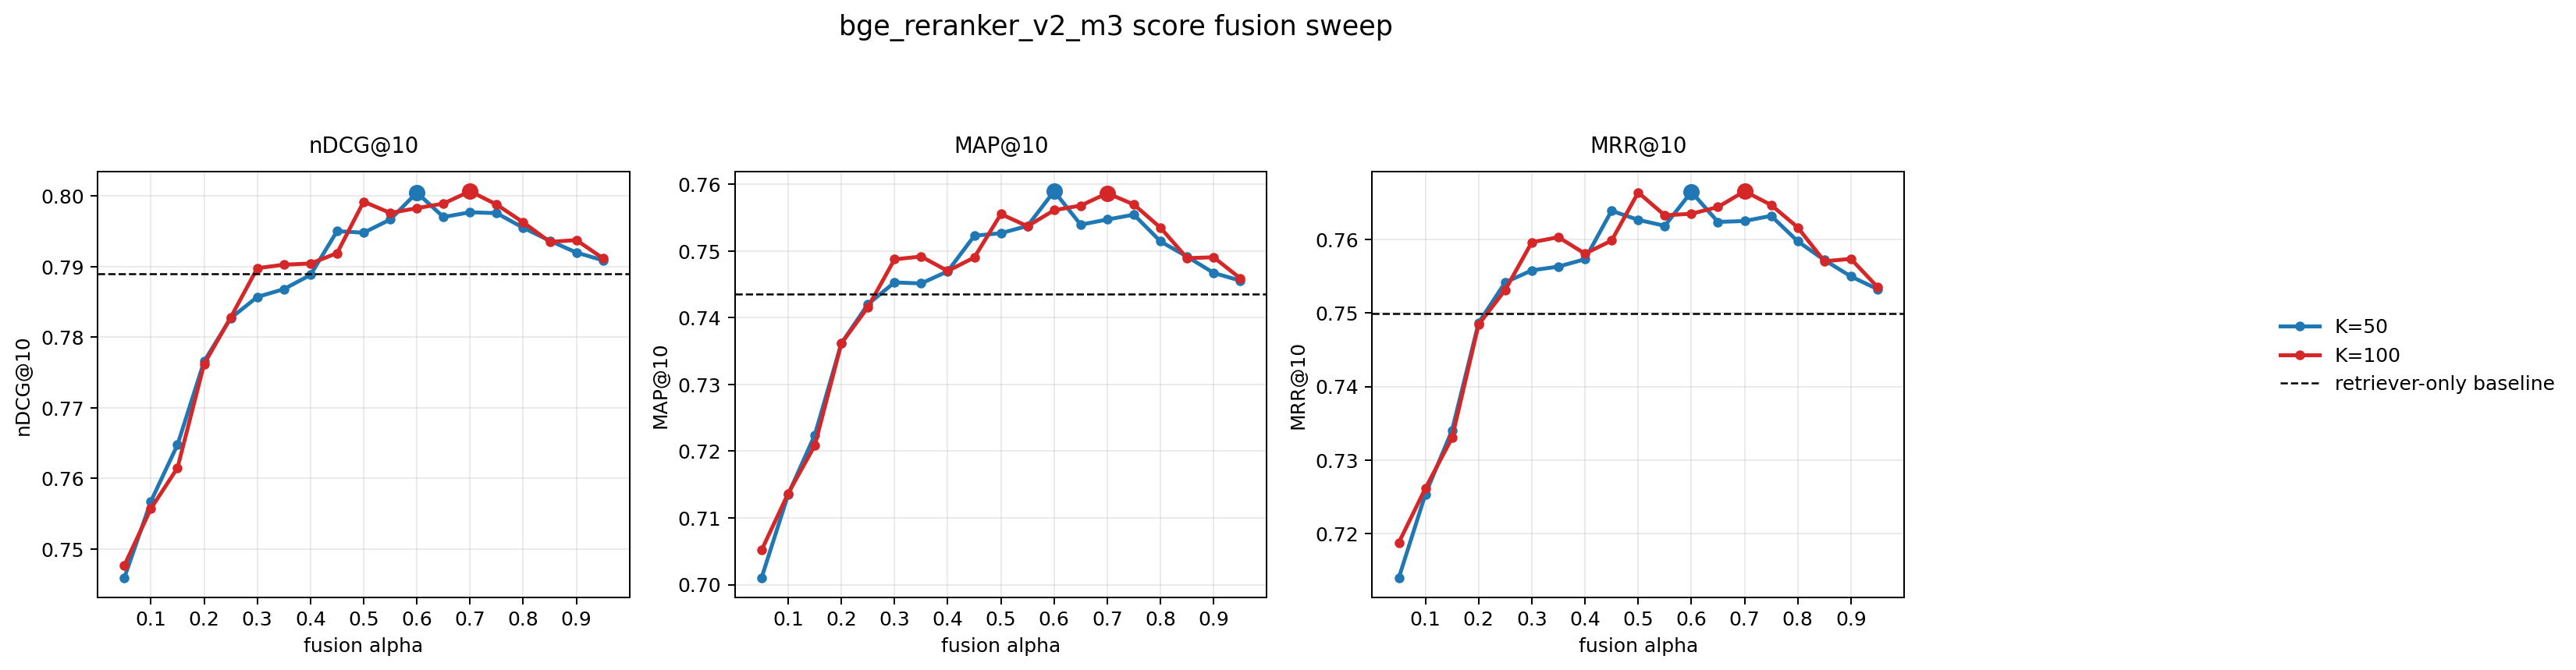

benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_fusion/alpha_plots/gte_reranker_modernbert_base_alpha_sweep.png


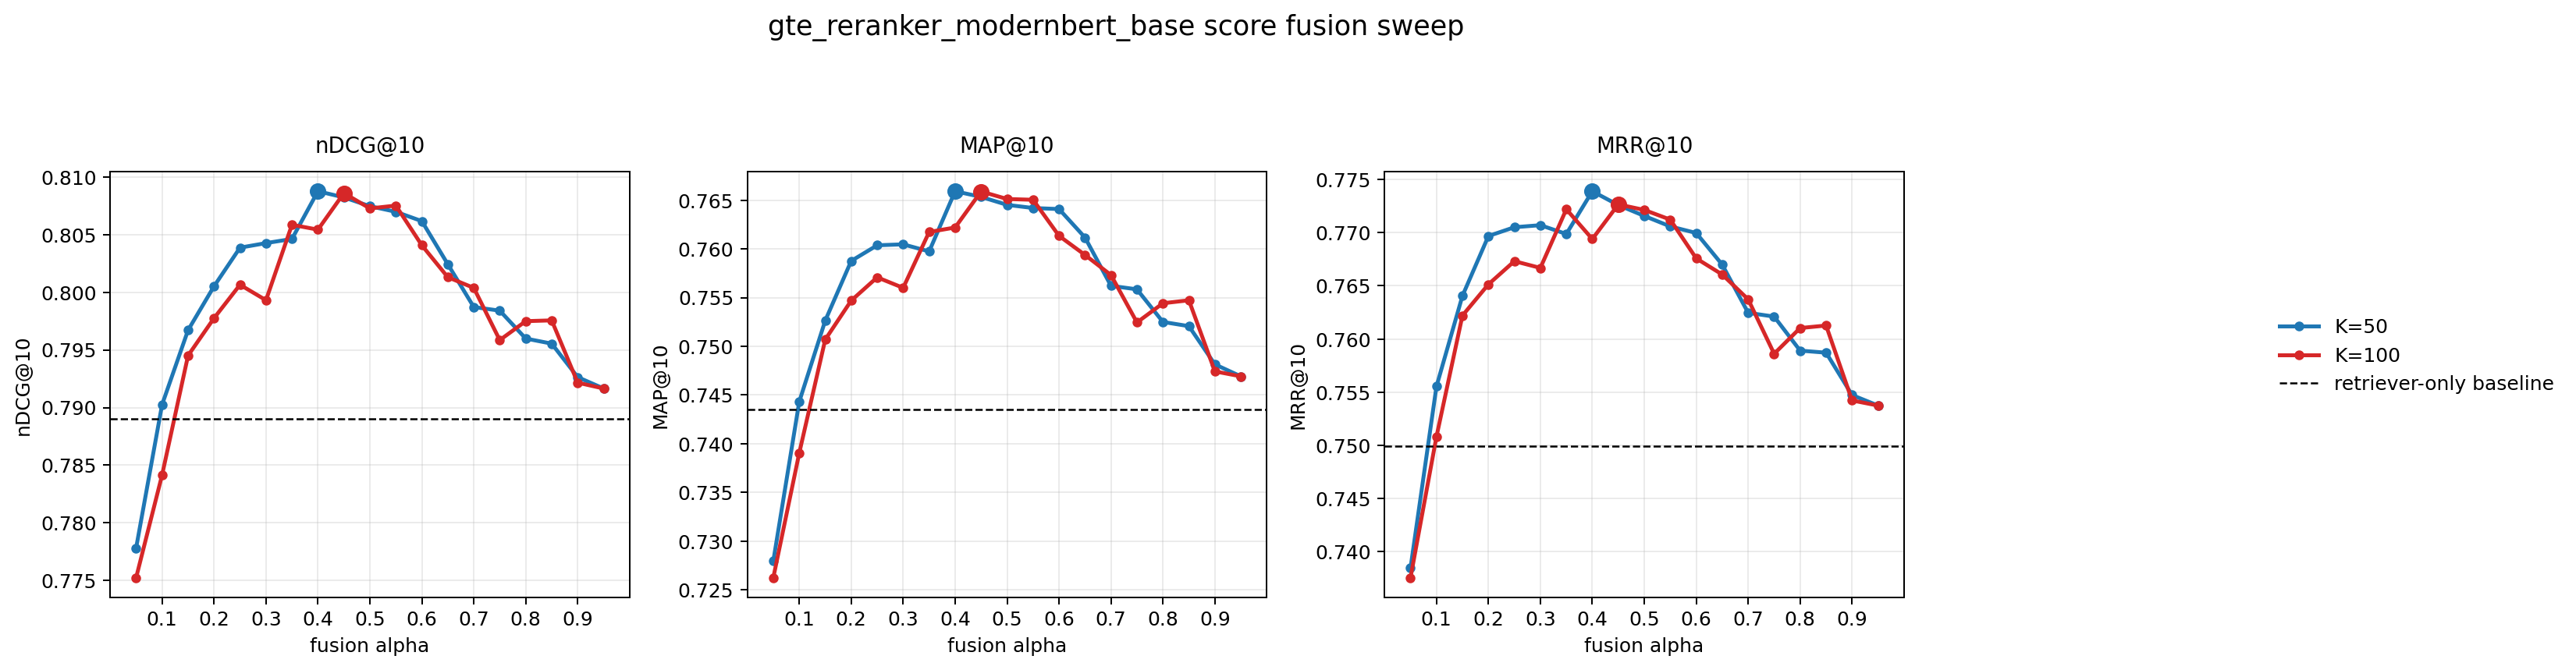

benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_fusion/alpha_plots/jina_reranker_v2_base_multilingual_alpha_sweep.png


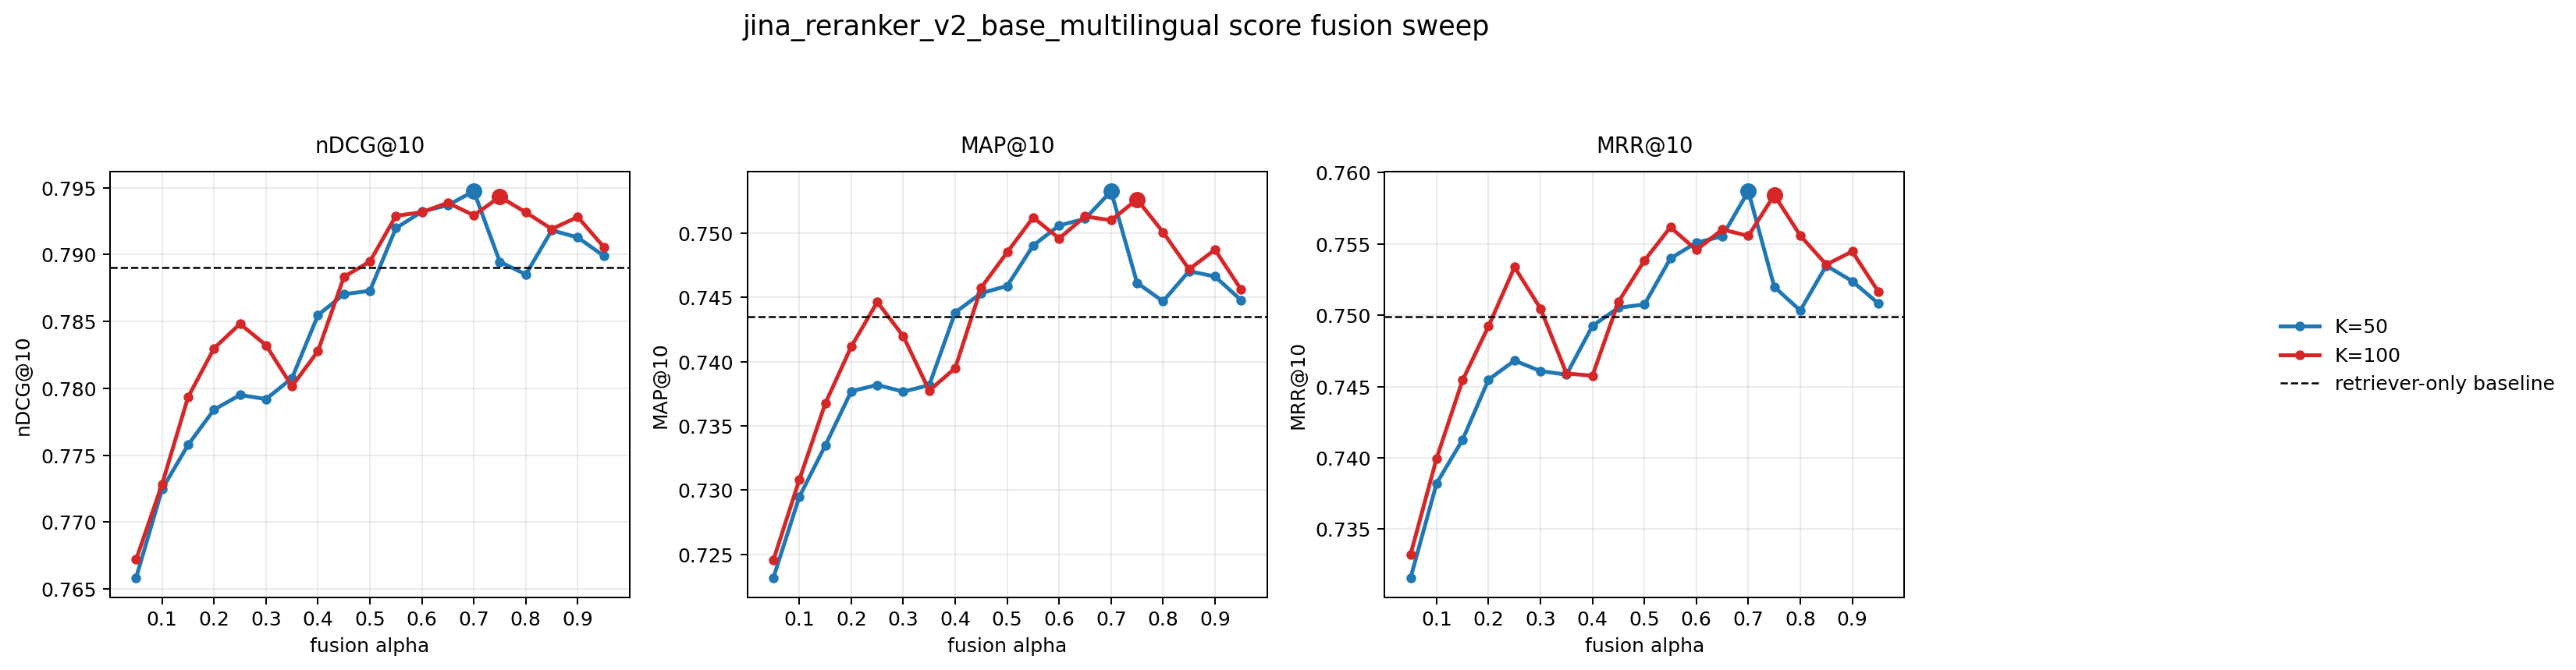

benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_fusion/alpha_plots/msmarco_minilm_l12_v2_alpha_sweep.png


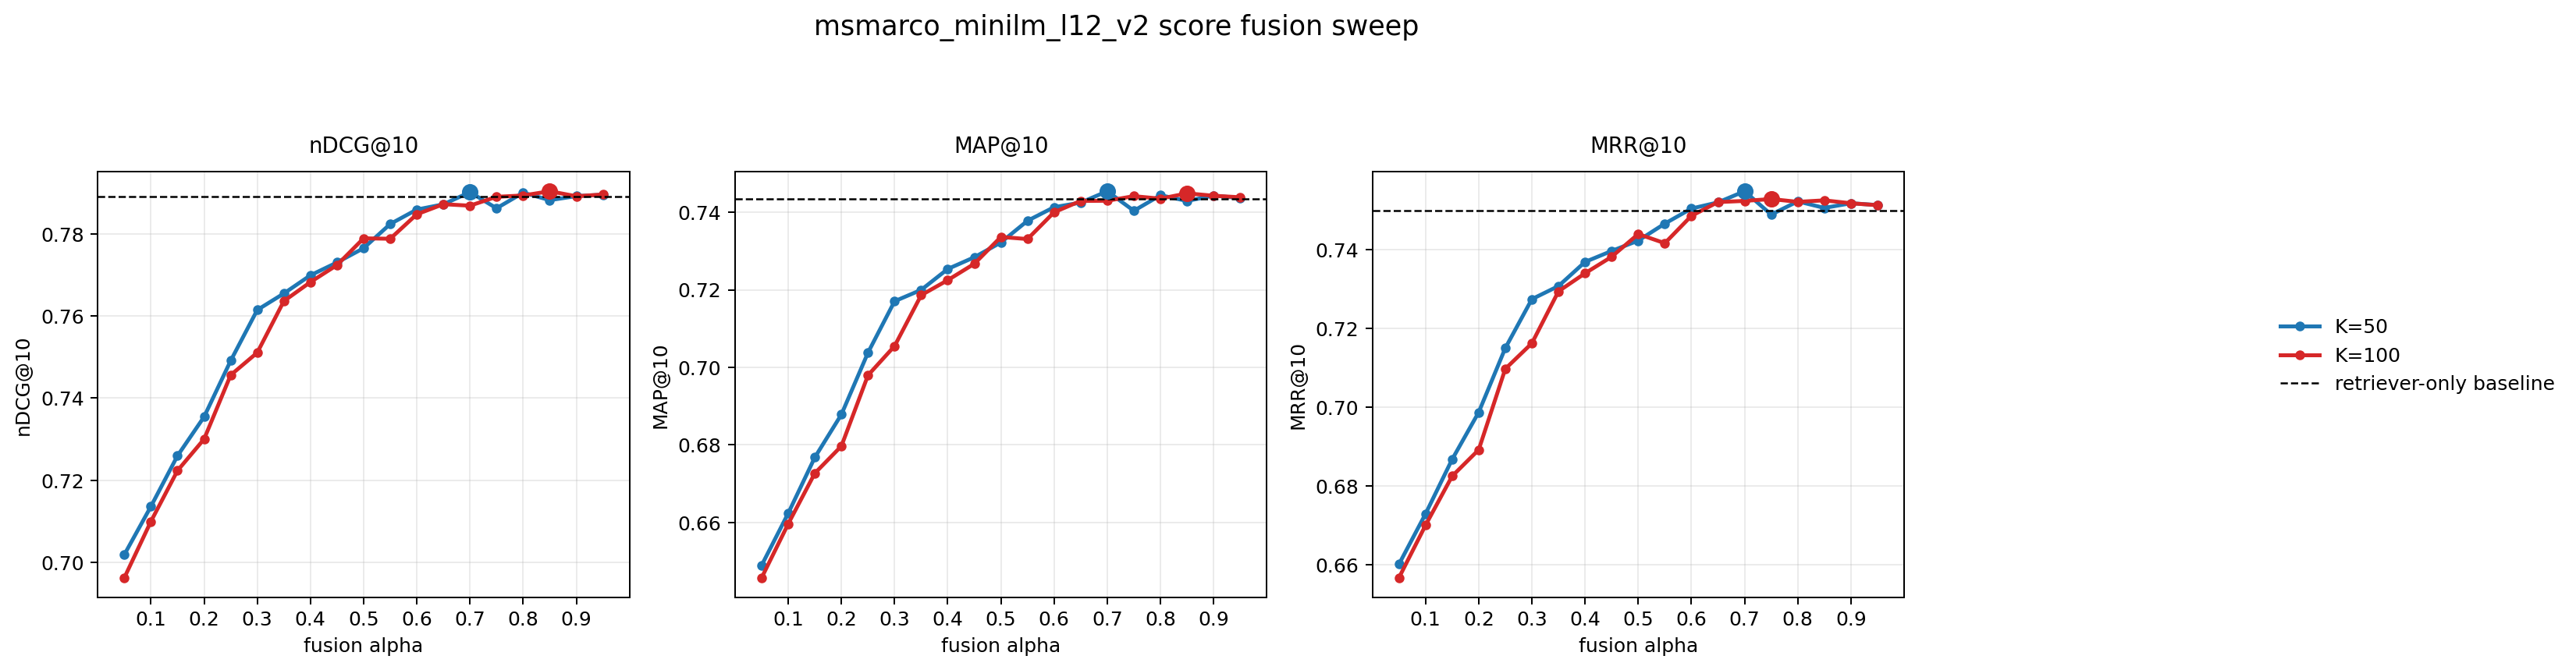

benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_fusion/alpha_plots/qwen3_reranker_0_6b_alpha_sweep.png


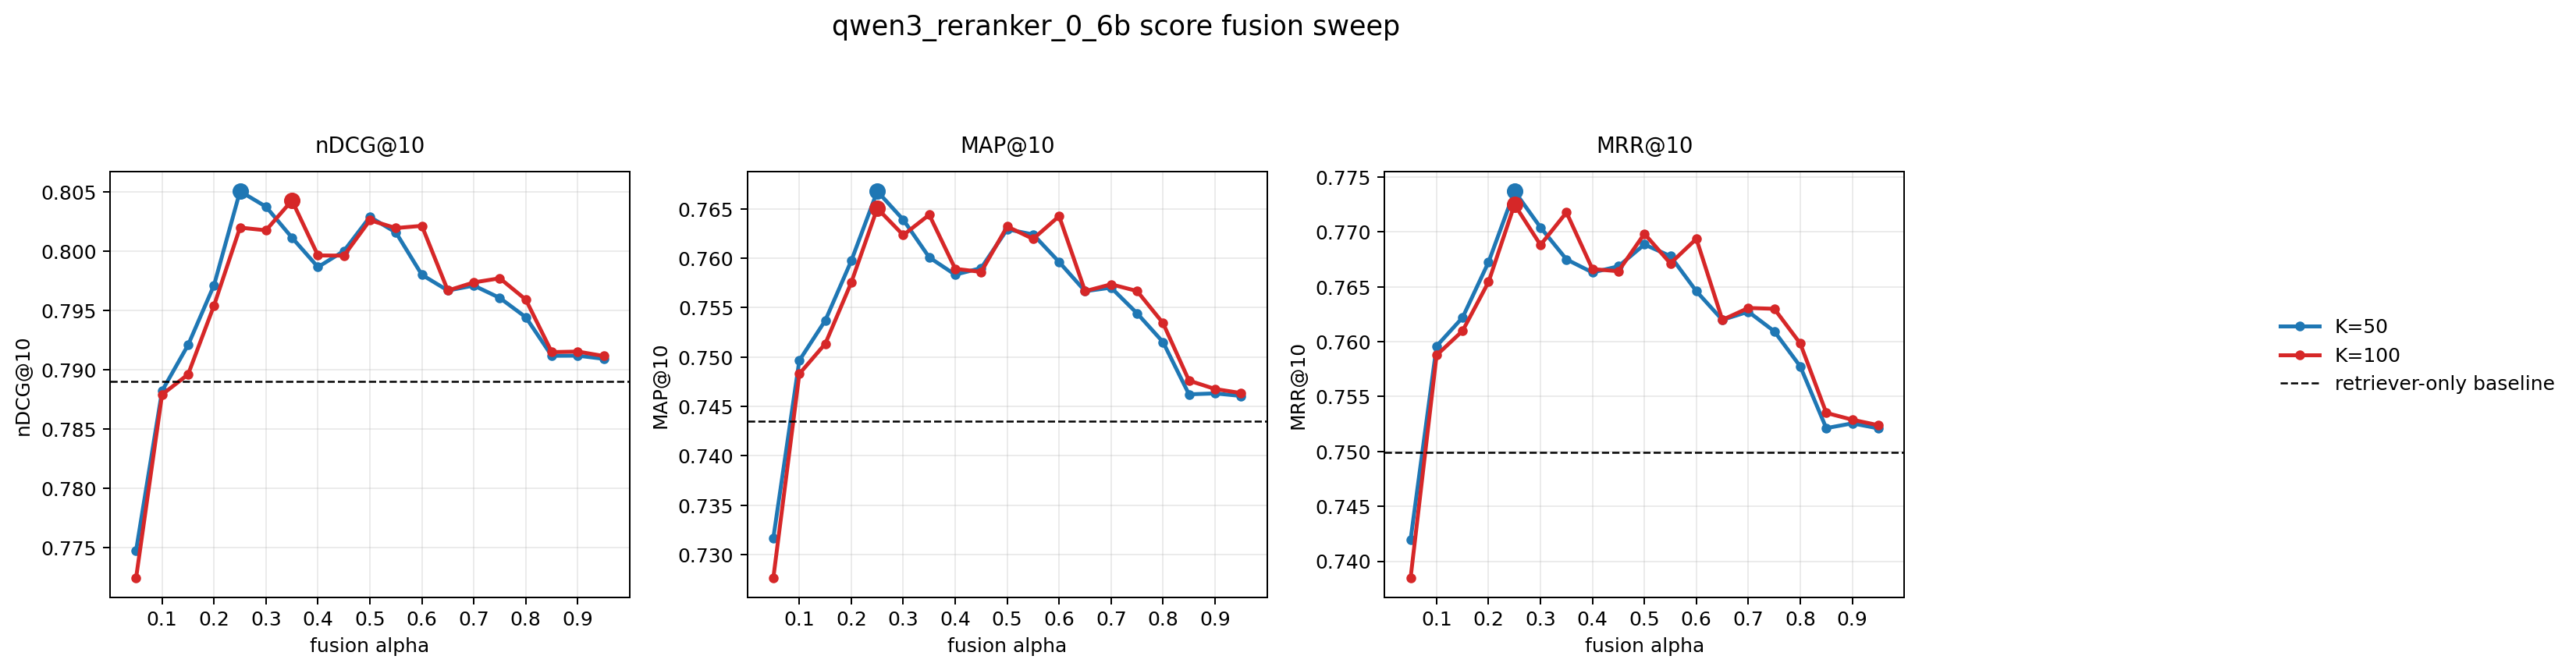

(            stage            retriever_model  \
 0    score_fusion  embeddinggemma_fact_check   
 1    score_fusion  embeddinggemma_fact_check   
 2    score_fusion  embeddinggemma_fact_check   
 3    score_fusion  embeddinggemma_fact_check   
 4    score_fusion  embeddinggemma_fact_check   
 ..            ...                        ...   
 196  score_fusion  embeddinggemma_fact_check   
 197  score_fusion  embeddinggemma_fact_check   
 198  score_fusion  embeddinggemma_fact_check   
 199      reranked  embeddinggemma_fact_check   
 200      reranked  embeddinggemma_fact_check   
 
                                 reranker_model  \
 0    gte_reranker_modernbert_base_fusion_a0.40   
 1    gte_reranker_modernbert_base_fusion_a0.45   
 2    gte_reranker_modernbert_base_fusion_a0.45   
 3    gte_reranker_modernbert_base_fusion_a0.55   
 4    gte_reranker_modernbert_base_fusion_a0.50   
 ..                                         ...   
 196         msmarco_minilm_l12_v2_fusion_a0.10   
 1

In [41]:
render_alpha_sweep_plots(
    summary_path=FUSION_OUTPUT_DIR / "summary.csv",
    plots_dir=FUSION_OUTPUT_DIR / "alpha_plots",
)



## Fine-Tuned GTE Fusion Follow-up

This section reruns the score-fusion experiment for the fine-tuned GTE reranker only. It keeps the same `embeddinggemma_fact_check` retriever and candidate sets, then compares the fine-tuned result against the original five-reranker fusion sweep.


In [35]:
from pathlib import Path
import json

# Set this to the hf_export directory produced by the fine-tuning notebook.
FINETUNED_GTE_MODEL_DIR = Path("experiments/scifact/results/scifact_gte_reranker_ft_20260510_175904/hf_export")
FINETUNED_GTE_LABEL = "gte_reranker_modernbert_base_finetuned"
FINETUNED_GTE_BATCH_SIZE = 32
FINETUNED_FUSION_OUTPUT_DIR = ACTIVE_RERANKER_RUN_DIR.parent / f"{ACTIVE_RERANKER_RUN_DIR.name}_finetuned_gte_fusion"
FINETUNED_FUSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "active_reranker_run_dir": str(ACTIVE_RERANKER_RUN_DIR),
    "finetuned_gte_model_dir": str(FINETUNED_GTE_MODEL_DIR),
    "finetuned_gte_batch_size": FINETUNED_GTE_BATCH_SIZE,
    "finetuned_fusion_output_dir": str(FINETUNED_FUSION_OUTPUT_DIR),
    "candidate_ks": CANDIDATE_KS,
    "fusion_alphas": FUSION_ALPHAS,
}, indent=2))




{
  "active_reranker_run_dir": "/content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744",
  "finetuned_gte_model_dir": "experiments/scifact/results/scifact_gte_reranker_ft_20260510_175904/hf_export",
  "finetuned_gte_batch_size": 32,
  "finetuned_fusion_output_dir": "/content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744_finetuned_gte_fusion",
  "candidate_ks": [
    50,
    100
  ],
  "fusion_alphas": [
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.35,
    0.4,
    0.45,
    0.5,
    0.55,
    0.6,
    0.65,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9,
    0.95
  ]
}


In [36]:
import json
import time

import numpy as np
import pandas as pd
from sentence_transformers import CrossEncoder

required_fusion_helpers = ["load_fusion_context", "run_fusion_for_score_lookup", "finalize_fusion_run"]
missing_fusion_helpers = [name for name in required_fusion_helpers if name not in globals()]
if missing_fusion_helpers:
    raise RuntimeError(
        "Run the `score-fusion-helpers` cell before this fine-tuned follow-up cell. "
        f"Missing helpers: {missing_fusion_helpers}"
    )

if not FINETUNED_GTE_MODEL_DIR.exists():
    raise FileNotFoundError(
        f"Fine-tuned GTE export not found at {FINETUNED_GTE_MODEL_DIR}. Run the fine-tuning notebook and point FINETUNED_GTE_MODEL_DIR to its hf_export directory."
    )

# Rebuild the file-backed retrieval/reranker context when this section is resumed
# after a Colab restart without rerunning the original score-fusion section.
if "FUSION_CONTEXT" not in globals():
    print("FUSION_CONTEXT not found; rebuilding it from ACTIVE_RERANKER_RUN_DIR.")
    FUSION_CONTEXT = load_fusion_context()

# Static reference from the earlier 5-reranker fusion sweep. This keeps the fine-tuned
# follow-up runnable after a Colab restart without reloading/recomputing old fusion outputs.
REFERENCE_BEST_EXISTING_FUSION = {
    "reranker_model": "gte_reranker_modernbert_base_fusion_a0.40",
    "candidate_k": 50,
    "ndcg_at_10": 0.808746,
    "map_at_10": 0.765916,
    "mrr_at_10": 0.773901,
    "avg_total_query_latency_ms": 422.090529,
}

ft_model = CrossEncoder(
    str(FINETUNED_GTE_MODEL_DIR),
    num_labels=1,
    max_length=1024,
    trust_remote_code=True,
)


def score_claim_abstract_pairs(queries, documents, batch_size=FINETUNED_GTE_BATCH_SIZE):
    pairs = list(zip(queries, documents, strict=True))
    scores = ft_model.predict(pairs, batch_size=batch_size, show_progress_bar=False)
    return np.asarray(scores, dtype=float).reshape(-1).tolist()


ft_rows = []
for candidate_k in [int(k) for k in CANDIDATE_KS]:
    rerank_start = time.perf_counter()
    score_lookup_by_query = {}
    for query_id in FUSION_CONTEXT["query_ids"]:
        candidate_ids = FUSION_CONTEXT["candidate_ids_by_query"][candidate_k][query_id]
        query_text = FUSION_CONTEXT["query_text_lookup"][query_id]
        candidate_texts = [FUSION_CONTEXT["corpus_text_lookup"][corpus_id] for corpus_id in candidate_ids]
        scores = score_claim_abstract_pairs([query_text] * len(candidate_ids), candidate_texts)
        score_lookup_by_query[query_id] = dict(zip(candidate_ids, scores, strict=True))
    reranker_seconds = time.perf_counter() - rerank_start
    ft_rows.extend(
        run_fusion_for_score_lookup(
            context=FUSION_CONTEXT,
            output_dir=FINETUNED_FUSION_OUTPUT_DIR,
            reranker_label=FINETUNED_GTE_LABEL,
            reranker_model_id=str(FINETUNED_GTE_MODEL_DIR),
            reranker_family="GTE ModernBERT fine-tuned on SciFact entailment",
            reranker_batch_size=FINETUNED_GTE_BATCH_SIZE,
            candidate_k=candidate_k,
            score_lookup_by_query=score_lookup_by_query,
            reranker_seconds=reranker_seconds,
            fusion_alphas=FUSION_ALPHAS,
            notes_prefix=f"Fine-tuned GTE reranker on SciFact entailment over top-{candidate_k} candidates.",
        )
    )

ft_summary, ft_report_path = finalize_fusion_run(
    output_dir=FINETUNED_FUSION_OUTPUT_DIR,
    rows=ft_rows,
    baseline_row=FUSION_CONTEXT["baseline_row"],
    config={
        "retriever_model": RETRIEVER_MODEL,
        "rerankers": [FINETUNED_GTE_LABEL],
        "candidate_ks": CANDIDATE_KS,
        "split": SPLIT,
        "document_mode": DOCUMENT_MODE,
        "fusion_alphas": FUSION_ALPHAS,
        "model_dir": str(FINETUNED_GTE_MODEL_DIR),
        "experiment_type": "finetuned_gte_score_fusion",
    },
)
ft_reranked_best = ft_summary[ft_summary["stage"] == "reranked"].sort_values(["ndcg_at_10", "map_at_10"], ascending=[False, False]).iloc[0]
ft_best = ft_summary[ft_summary["stage"] == "score_fusion"].sort_values(["ndcg_at_10", "map_at_10"], ascending=[False, False]).iloc[0]
comparison_table = pd.DataFrame([
    {
        "label": "reference_best_existing_fusion",
        "reranker": REFERENCE_BEST_EXISTING_FUSION["reranker_model"],
        "candidate_k": int(REFERENCE_BEST_EXISTING_FUSION["candidate_k"]),
        "ndcg_at_10": float(REFERENCE_BEST_EXISTING_FUSION["ndcg_at_10"]),
        "map_at_10": float(REFERENCE_BEST_EXISTING_FUSION["map_at_10"]),
        "mrr_at_10": float(REFERENCE_BEST_EXISTING_FUSION["mrr_at_10"]),
        "avg_total_query_latency_ms": float(REFERENCE_BEST_EXISTING_FUSION["avg_total_query_latency_ms"]),
    },
    {
        "label": "finetuned_gte_rerank_only",
        "reranker": ft_reranked_best["reranker_model"],
        "candidate_k": int(ft_reranked_best["candidate_k"]),
        "ndcg_at_10": float(ft_reranked_best["ndcg_at_10"]),
        "map_at_10": float(ft_reranked_best["map_at_10"]),
        "mrr_at_10": float(ft_reranked_best["mrr_at_10"]),
        "avg_total_query_latency_ms": float(ft_reranked_best["avg_total_query_latency_ms"]),
    },
    {
        "label": "best_finetuned_gte_fusion",
        "reranker": ft_best["reranker_model"],
        "candidate_k": int(ft_best["candidate_k"]),
        "ndcg_at_10": float(ft_best["ndcg_at_10"]),
        "map_at_10": float(ft_best["map_at_10"]),
        "mrr_at_10": float(ft_best["mrr_at_10"]),
        "avg_total_query_latency_ms": float(ft_best["avg_total_query_latency_ms"]),
    },
])
print(f"Wrote fine-tuned fusion summary to {FINETUNED_FUSION_OUTPUT_DIR / 'summary.csv'}")
print(f"Wrote fine-tuned fusion report to {ft_report_path}")
display(comparison_table)







W0510 19:02:40.548000 13784 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Wrote fine-tuned fusion summary to /content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744_finetuned_gte_fusion/summary.csv
Wrote fine-tuned fusion report to /content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744_finetuned_gte_fusion/REPORT.md


,label,reranker,candidate_k,ndcg_at_10,map_at_10,mrr_at_10,avg_total_query_latency_ms
0,reference_best_existing_fusion,gte_reranker_modernbert_base_fusion_a0.40,50,0.808746,0.765916,0.773901,422.090529
1,finetuned_gte_rerank_only,gte_reranker_modernbert_base_finetuned,50,0.727556,0.680677,0.698923,2429.071113
2,best_finetuned_gte_fusion,gte_reranker_modernbert_base_finetuned_fusion_...,100,0.793750,0.747950,0.757110,4103.887588


# SciFact Reranker Report

## Run configuration

- Retriever: `embeddinggemma_fact_check`
- Split: `test`
- Document mode: `abstract`
- Candidate Ks: `[50, 100]`
- Rerankers: `gte_reranker_modernbert_base_finetuned`

## Headline results

- Best `nDCG@10`: `gte_reranker_modernbert_base_finetuned_fusion_a0.70@100` at `0.7938`
- Best `MAP@10`: `gte_reranker_modernbert_base_finetuned_fusion_a0.70@100` at `0.7479`
- Lowest average total query latency: `embeddinggemma_fact_check` at `1.23 ms`

## Metrics table

| Label | Stage | Candidate K | Stage1 Recall@K | nDCG@10 | MRR@10 | MAP@10 | Recall@10 | Avg Rerank (ms) | Avg Total Query (ms) |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| gte_reranker_modernbert_base_finetuned_fusion_a0.70@100 | score_fusion | 100 | 0.9833 | 0.7938 | 0.7571 | 0.7479 | 0.9229 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.65@50 | score_fusion | 50 | 0.9650 | 0.7919 | 0.7547 | 0.7456 | 0.9229 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.65@100 | score_fusion | 100 | 0.9833 | 0.7908 | 0.7533 | 0.7442 | 0.9229 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.60@100 | score_fusion | 100 | 0.9833 | 0.7905 | 0.7544 | 0.7437 | 0.9212 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.70@50 | score_fusion | 50 | 0.9650 | 0.7905 | 0.7541 | 0.7455 | 0.9169 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.75@100 | score_fusion | 100 | 0.9833 | 0.7897 | 0.7531 | 0.7443 | 0.9169 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.85@100 | score_fusion | 100 | 0.9833 | 0.7894 | 0.7515 | 0.7440 | 0.9176 | 4102.66 | 4103.89 |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.23 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.60@50 | score_fusion | 50 | 0.9650 | 0.7888 | 0.7509 | 0.7413 | 0.9229 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.95@100 | score_fusion | 100 | 0.9833 | 0.7873 | 0.7476 | 0.7409 | 0.9192 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.90@50 | score_fusion | 50 | 0.9650 | 0.7873 | 0.7476 | 0.7410 | 0.9192 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.90@100 | score_fusion | 100 | 0.9833 | 0.7872 | 0.7478 | 0.7405 | 0.9192 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.95@50 | score_fusion | 50 | 0.9650 | 0.7867 | 0.7468 | 0.7402 | 0.9192 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.85@50 | score_fusion | 50 | 0.9650 | 0.7865 | 0.7477 | 0.7401 | 0.9176 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.80@100 | score_fusion | 100 | 0.9833 | 0.7865 | 0.7477 | 0.7399 | 0.9176 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.75@50 | score_fusion | 50 | 0.9650 | 0.7865 | 0.7480 | 0.7398 | 0.9176 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.80@50 | score_fusion | 50 | 0.9650 | 0.7856 | 0.7467 | 0.7388 | 0.9176 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.55@50 | score_fusion | 50 | 0.9650 | 0.7815 | 0.7424 | 0.7317 | 0.9212 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.55@100 | score_fusion | 100 | 0.9833 | 0.7814 | 0.7406 | 0.7308 | 0.9246 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.50@50 | score_fusion | 50 | 0.9650 | 0.7779 | 0.7359 | 0.7261 | 0.9246 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.50@100 | score_fusion | 100 | 0.9833 | 0.7770 | 0.7356 | 0.7255 | 0.9229 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.40@50 | score_fusion | 50 | 0.9650 | 0.7768 | 0.7344 | 0.7247 | 0.9246 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.45@50 | score_fusion | 50 | 0.9650 | 0.7759 | 0.7333 | 0.7234 | 0.9246 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.45@100 | score_fusion | 100 | 0.9833 | 0.7754 | 0.7336 | 0.7234 | 0.9229 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.35@50 | score_fusion | 50 | 0.9650 | 0.7749 | 0.7322 | 0.7224 | 0.9246 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.40@100 | score_fusion | 100 | 0.9833 | 0.7735 | 0.7312 | 0.7210 | 0.9229 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.30@50 | score_fusion | 50 | 0.9650 | 0.7732 | 0.7311 | 0.7212 | 0.9212 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.25@50 | score_fusion | 50 | 0.9650 | 0.7713 | 0.7296 | 0.7186 | 0.9212 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.35@100 | score_fusion | 100 | 0.9833 | 0.7704 | 0.7292 | 0.7190 | 0.9162 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.20@50 | score_fusion | 50 | 0.9650 | 0.7698 | 0.7274 | 0.7168 | 0.9212 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.30@100 | score_fusion | 100 | 0.9833 | 0.7680 | 0.7261 | 0.7159 | 0.9162 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.15@50 | score_fusion | 50 | 0.9650 | 0.7671 | 0.7259 | 0.7152 | 0.9146 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.25@100 | score_fusion | 100 | 0.9833 | 0.7671 | 0.7258 | 0.7148 | 0.9162 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.20@100 | score_fusion | 100 | 0.9833 | 0.7635 | 0.7232 | 0.7122 | 0.9096 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.10@50 | score_fusion | 50 | 0.9650 | 0.7626 | 0.7232 | 0.7118 | 0.9062 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.15@100 | score_fusion | 100 | 0.9833 | 0.7618 | 0.7213 | 0.7102 | 0.9096 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.10@100 | score_fusion | 100 | 0.9833 | 0.7602 | 0.7216 | 0.7102 | 0.9029 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.05@50 | score_fusion | 50 | 0.9650 | 0.7586 | 0.7203 | 0.7088 | 0.8996 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned_fusion_a0.05@100 | score_fusion | 100 | 0.9833 | 0.7516 | 0.7156 | 0.7040 | 0.8862 | 4102.66 | 4103.89 |
| gte_reranker_modernbert_base_finetuned@50 | reranked | 50 | 0.9650 | 0.7276 | 0.6989 | 0.6807 | 0.8546 | 2427.85 | 2429.07 |
| gte_reranker_modernbert_base_finetuned@100 | reranked | 100 | 0.9833 | 0.7120 | 0.6877 | 0.6696 | 0.8246 | 4102.66 | 4103.89 |

## Plots

- `plots/ndcg_at_10.png`
- `plots/mrr_at_10.png`
- `plots/map_at_10.png`
- `plots/avg_total_query_latency_ms.png`
- `plots/ndcg_vs_total_query_latency.png`


,base_reranker,candidate_k,alpha,ndcg_at_10,map_at_10,mrr_at_10,avg_total_query_latency_ms
1,gte_reranker_modernbert_base_finetuned,100,0.70,0.793750,0.747950,0.757110,4103.887588
0,gte_reranker_modernbert_base_finetuned,50,0.65,0.791917,0.745553,0.754673,2429.071113


/content/drive/MyDrive/scholarrag/colab_scifact_rerank_20260430_183744_finetuned_gte_fusion/alpha_plots/gte_reranker_modernbert_base_finetuned_alpha_sweep.png


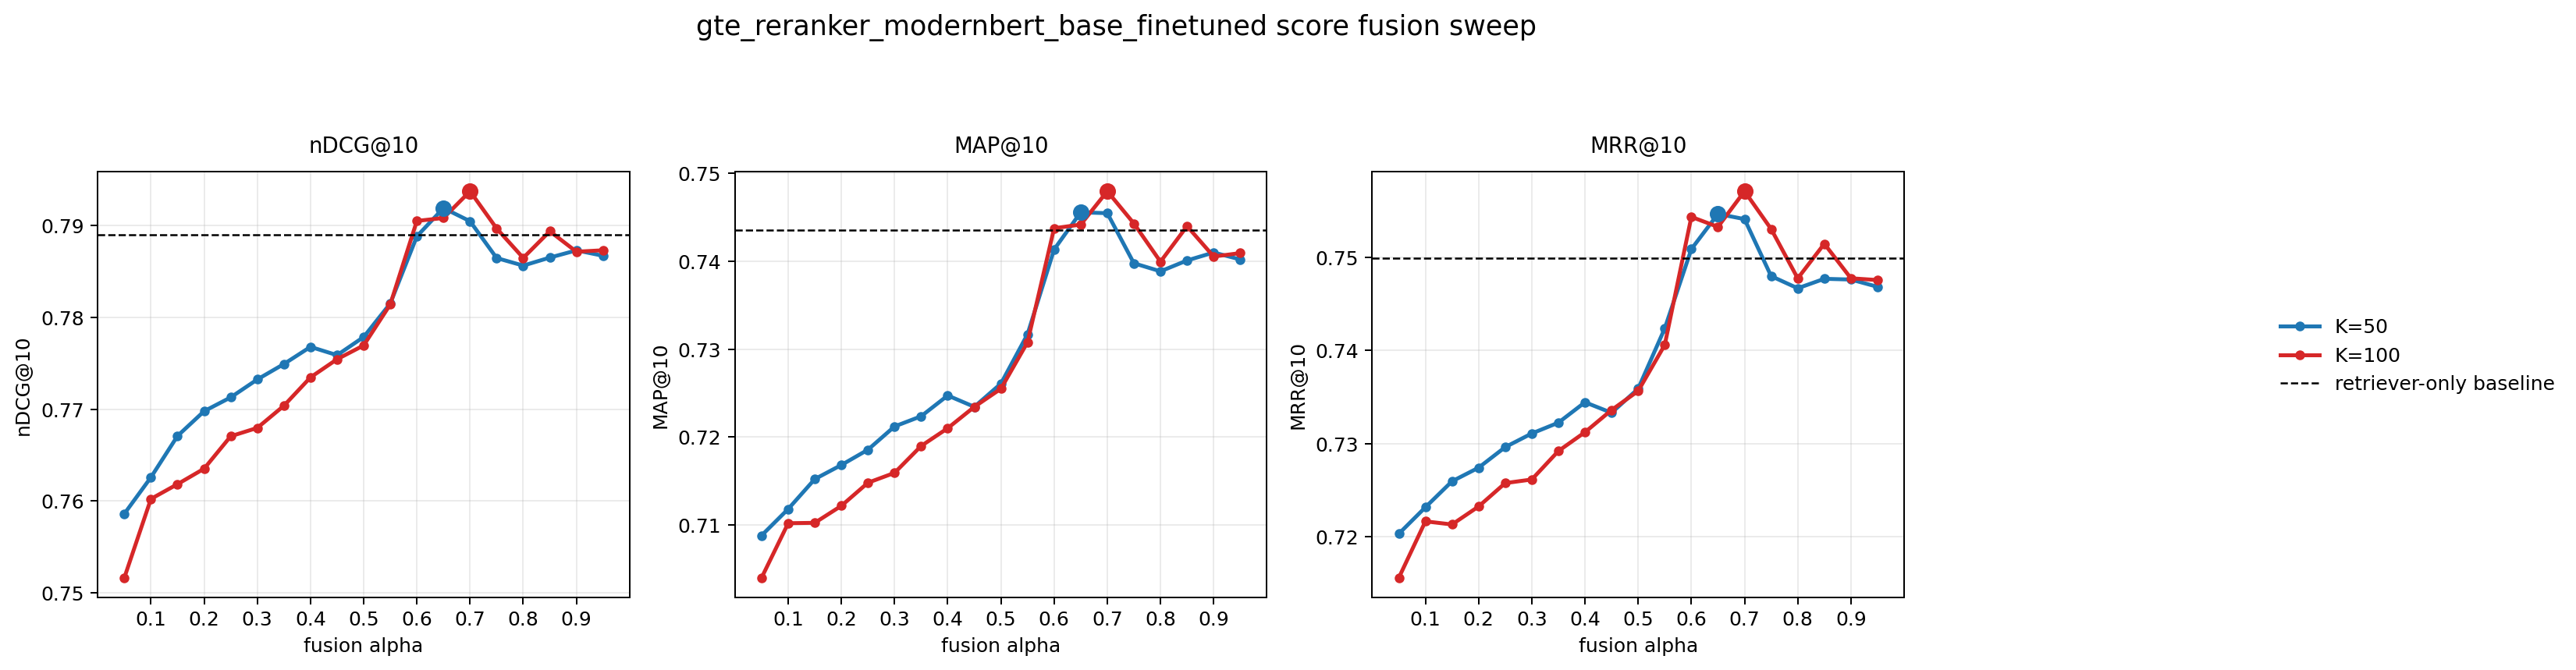

(             stage            retriever_model  \
 0     score_fusion  embeddinggemma_fact_check   
 1     score_fusion  embeddinggemma_fact_check   
 2     score_fusion  embeddinggemma_fact_check   
 3     score_fusion  embeddinggemma_fact_check   
 4     score_fusion  embeddinggemma_fact_check   
 5     score_fusion  embeddinggemma_fact_check   
 6     score_fusion  embeddinggemma_fact_check   
 7   retriever_only  embeddinggemma_fact_check   
 8     score_fusion  embeddinggemma_fact_check   
 9     score_fusion  embeddinggemma_fact_check   
 10    score_fusion  embeddinggemma_fact_check   
 11    score_fusion  embeddinggemma_fact_check   
 12    score_fusion  embeddinggemma_fact_check   
 13    score_fusion  embeddinggemma_fact_check   
 14    score_fusion  embeddinggemma_fact_check   
 15    score_fusion  embeddinggemma_fact_check   
 16    score_fusion  embeddinggemma_fact_check   
 17    score_fusion  embeddinggemma_fact_check   
 18    score_fusion  embeddinggemma_fact_check   


In [37]:
render_alpha_sweep_plots(
    summary_path=FINETUNED_FUSION_OUTPUT_DIR / "summary.csv",
    plots_dir=FINETUNED_FUSION_OUTPUT_DIR / "alpha_plots",
    title_suffix=f"{FINETUNED_GTE_LABEL} score fusion sweep",
    show_report_path=FINETUNED_FUSION_OUTPUT_DIR / "REPORT.md",
)



## Jina v3 Listwise Follow-up

This is a separate exploratory test for `jina-reranker-v3`, not part of the main pairwise reranker bake-off.

Why separate:
- it is a listwise reranker, not a standard pairwise cross-encoder
- it uses a different `model.rerank(query, documents)` API
- we keep it at `K=50` so the whole candidate list can be reranked together

Plan:
1. compare `Gemma retriever-only` vs `Gemma + Jina v3 rerank@50`
2. if the pure rerank is still not enough, run a small fusion sweep on top of that

License note: `jinaai/jina-reranker-v3` is `CC-BY-NC-4.0`, so this is fine for research evaluation but not a safe default for commercial production.


In [24]:
from pathlib import Path
import json

JINA_V3_MODEL_ID = "jinaai/jina-reranker-v3"
JINA_V3_LABEL = "jina_reranker_v3_listwise"
JINA_V3_CANDIDATE_K = 50
JINA_V3_OUTPUT_DIR = ACTIVE_RERANKER_RUN_DIR.parent / f"{ACTIVE_RERANKER_RUN_DIR.name}_jina_v3"
JINA_V3_FUSION_OUTPUT_DIR = ACTIVE_RERANKER_RUN_DIR.parent / f"{ACTIVE_RERANKER_RUN_DIR.name}_jina_v3_fusion"
JINA_V3_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JINA_V3_FUSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "active_reranker_run_dir": str(ACTIVE_RERANKER_RUN_DIR),
    "jina_v3_model_id": JINA_V3_MODEL_ID,
    "candidate_k": JINA_V3_CANDIDATE_K,
    "jina_v3_output_dir": str(JINA_V3_OUTPUT_DIR),
    "jina_v3_fusion_output_dir": str(JINA_V3_FUSION_OUTPUT_DIR),
}, indent=2))


{
  "active_reranker_run_dir": "benchmarks/scifact/results/colab_scifact_rerank_20260430_183744",
  "jina_v3_model_id": "jinaai/jina-reranker-v3",
  "candidate_k": 50,
  "jina_v3_output_dir": "benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3",
  "jina_v3_fusion_output_dir": "benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3_fusion"
}


In [25]:
import json
import time

import numpy as np
import pandas as pd
from transformers import AutoModel

jina_v3_model = AutoModel.from_pretrained(
    JINA_V3_MODEL_ID,
    dtype="auto",
    trust_remote_code=True,
)
jina_v3_model.eval()
if hasattr(jina_v3_model, "to"):
    try:
        jina_v3_model.to(DEVICE)
    except Exception:
        pass

rerank_start = time.perf_counter()
jina_v3_score_lookup_by_query = {}
for query_id in FUSION_CONTEXT["query_ids"]:
    candidate_ids = FUSION_CONTEXT["candidate_ids_by_query"][JINA_V3_CANDIDATE_K][query_id]
    query_text = FUSION_CONTEXT["query_text_lookup"][query_id]
    candidate_texts = [FUSION_CONTEXT["corpus_text_lookup"][corpus_id] for corpus_id in candidate_ids]
    rerank_results = jina_v3_model.rerank(query_text, candidate_texts)
    score_lookup = {candidate_ids[int(item["index"])]: float(item["relevance_score"]) for item in rerank_results}
    jina_v3_score_lookup_by_query[query_id] = score_lookup
jina_v3_reranker_seconds = time.perf_counter() - rerank_start

jina_v3_rows = run_fusion_for_score_lookup(
    context=FUSION_CONTEXT,
    output_dir=JINA_V3_OUTPUT_DIR,
    reranker_label=JINA_V3_LABEL,
    reranker_model_id=JINA_V3_MODEL_ID,
    reranker_family="Jina v3 listwise reranker",
    reranker_batch_size=JINA_V3_CANDIDATE_K,
    candidate_k=JINA_V3_CANDIDATE_K,
    score_lookup_by_query=jina_v3_score_lookup_by_query,
    reranker_seconds=jina_v3_reranker_seconds,
    fusion_alphas=[],
    notes_prefix="Pure Jina v3 listwise rerank over Gemma top-50 candidates.",
)
jina_v3_summary, jina_v3_report_path = finalize_fusion_run(
    output_dir=JINA_V3_OUTPUT_DIR,
    rows=jina_v3_rows,
    baseline_row=FUSION_CONTEXT["baseline_row"],
    config={
        "retriever_model": RETRIEVER_MODEL,
        "rerankers": [JINA_V3_LABEL],
        "candidate_ks": [JINA_V3_CANDIDATE_K],
        "split": SPLIT,
        "document_mode": DOCUMENT_MODE,
        "model_id": JINA_V3_MODEL_ID,
        "experiment_type": "jina_v3_rerank_only",
        "source_reranker_run_dir": str(ACTIVE_RERANKER_RUN_DIR),
    },
)
jina_v3_reranked = jina_v3_summary[jina_v3_summary["stage"] == "reranked"].iloc[0]
baseline_row = jina_v3_summary[jina_v3_summary["stage"] == "retriever_only"].iloc[0]
jina_v3_compare = pd.DataFrame([
    {
        "label": "gemma_retriever_only",
        "ndcg_at_10": float(baseline_row["ndcg_at_10"]),
        "map_at_10": float(baseline_row["map_at_10"]),
        "mrr_at_10": float(baseline_row["mrr_at_10"]),
        "avg_total_query_latency_ms": float(baseline_row["avg_total_query_latency_ms"]),
    },
    {
        "label": "gemma_plus_jina_v3_rerank50",
        "ndcg_at_10": float(jina_v3_reranked["ndcg_at_10"]),
        "map_at_10": float(jina_v3_reranked["map_at_10"]),
        "mrr_at_10": float(jina_v3_reranked["mrr_at_10"]),
        "avg_total_query_latency_ms": float(jina_v3_reranked["avg_total_query_latency_ms"]),
    },
])
print(f"Wrote Jina v3 rerank-only summary to {JINA_V3_OUTPUT_DIR / 'summary.csv'}")
print(f"Wrote Jina v3 rerank-only report to {jina_v3_report_path}")
display(jina_v3_compare)


config.json:   0%|          | 0.00/828 [00:00<?, ?B/s]

modeling.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-reranker-v3:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/202 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

Wrote Jina v3 rerank-only summary to benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3/summary.csv
Wrote Jina v3 rerank-only report to benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3/REPORT.md


,label,ndcg_at_10,map_at_10,mrr_at_10,avg_total_query_latency_ms
0,gemma_retriever_only,0.789013,0.743504,0.749906,1.225971
1,gemma_plus_jina_v3_rerank50,0.772041,0.730206,0.738341,1613.863397


In [26]:
import json

jina_v3_fusion_rows = run_fusion_for_score_lookup(
    context=FUSION_CONTEXT,
    output_dir=JINA_V3_FUSION_OUTPUT_DIR,
    reranker_label=JINA_V3_LABEL,
    reranker_model_id=JINA_V3_MODEL_ID,
    reranker_family="Jina v3 listwise reranker",
    reranker_batch_size=JINA_V3_CANDIDATE_K,
    candidate_k=JINA_V3_CANDIDATE_K,
    score_lookup_by_query=jina_v3_score_lookup_by_query,
    reranker_seconds=jina_v3_reranker_seconds,
    fusion_alphas=FUSION_ALPHAS,
    notes_prefix="Jina v3 listwise rerank over Gemma top-50 candidates, followed by score fusion.",
)
jina_v3_fusion_summary, jina_v3_fusion_report_path = finalize_fusion_run(
    output_dir=JINA_V3_FUSION_OUTPUT_DIR,
    rows=jina_v3_fusion_rows,
    baseline_row=FUSION_CONTEXT["baseline_row"],
    config={
        "retriever_model": RETRIEVER_MODEL,
        "rerankers": [JINA_V3_LABEL],
        "candidate_ks": [JINA_V3_CANDIDATE_K],
        "split": SPLIT,
        "document_mode": DOCUMENT_MODE,
        "fusion_alphas": FUSION_ALPHAS,
        "model_id": JINA_V3_MODEL_ID,
        "experiment_type": "jina_v3_fusion",
        "source_reranker_run_dir": str(ACTIVE_RERANKER_RUN_DIR),
    },
)
jina_v3_fusion_best = jina_v3_fusion_summary[jina_v3_fusion_summary["stage"] == "score_fusion"].sort_values(["ndcg_at_10", "map_at_10"], ascending=[False, False]).iloc[0]
existing_best = fusion_summary[fusion_summary["stage"] == "score_fusion"].sort_values(["ndcg_at_10", "map_at_10"], ascending=[False, False]).iloc[0]
jina_v3_fusion_compare = pd.DataFrame([
    {
        "label": "best_existing_pairwise_fusion",
        "reranker": existing_best["reranker_model"],
        "ndcg_at_10": float(existing_best["ndcg_at_10"]),
        "map_at_10": float(existing_best["map_at_10"]),
        "avg_total_query_latency_ms": float(existing_best["avg_total_query_latency_ms"]),
    },
    {
        "label": "best_jina_v3_fusion",
        "reranker": jina_v3_fusion_best["reranker_model"],
        "ndcg_at_10": float(jina_v3_fusion_best["ndcg_at_10"]),
        "map_at_10": float(jina_v3_fusion_best["map_at_10"]),
        "avg_total_query_latency_ms": float(jina_v3_fusion_best["avg_total_query_latency_ms"]),
    },
])
print(f"Wrote Jina v3 fusion summary to {JINA_V3_FUSION_OUTPUT_DIR / 'summary.csv'}")
print(f"Wrote Jina v3 fusion report to {jina_v3_fusion_report_path}")
display(jina_v3_fusion_compare)


Wrote Jina v3 fusion summary to benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3_fusion/summary.csv
Wrote Jina v3 fusion report to benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3_fusion/REPORT.md


,label,reranker,ndcg_at_10,map_at_10,avg_total_query_latency_ms
0,best_existing_pairwise_fusion,gte_reranker_modernbert_base_fusion_a0.40,0.808746,0.765916,422.090529
1,best_jina_v3_fusion,jina_reranker_v3_listwise_fusion_a0.55,0.809564,0.769715,1613.863397


# SciFact Reranker Report

## Run configuration

- Retriever: `embeddinggemma_fact_check`
- Split: `test`
- Document mode: `abstract`
- Candidate Ks: `[50]`
- Rerankers: `jina_reranker_v3_listwise`

## Headline results

- Best `nDCG@10`: `embeddinggemma_fact_check` at `0.7890`
- Best `MAP@10`: `embeddinggemma_fact_check` at `0.7435`
- Lowest average total query latency: `embeddinggemma_fact_check` at `1.23 ms`

## Metrics table

| Label | Stage | Candidate K | Stage1 Recall@K | nDCG@10 | MRR@10 | MAP@10 | Recall@10 | Avg Rerank (ms) | Avg Total Query (ms) |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.23 |
| jina_reranker_v3_listwise@50 | reranked | 50 | 0.9650 | 0.7720 | 0.7383 | 0.7302 | 0.8910 | 1612.64 | 1613.86 |

## Plots

- `plots/ndcg_at_10.png`
- `plots/mrr_at_10.png`
- `plots/map_at_10.png`
- `plots/avg_total_query_latency_ms.png`
- `plots/ndcg_vs_total_query_latency.png`


# SciFact Reranker Report

## Run configuration

- Retriever: `embeddinggemma_fact_check`
- Split: `test`
- Document mode: `abstract`
- Candidate Ks: `[50]`
- Rerankers: `jina_reranker_v3_listwise`

## Headline results

- Best `nDCG@10`: `jina_reranker_v3_listwise_fusion_a0.55@50` at `0.8096`
- Best `MAP@10`: `jina_reranker_v3_listwise_fusion_a0.55@50` at `0.7697`
- Lowest average total query latency: `embeddinggemma_fact_check` at `1.23 ms`

## Metrics table

| Label | Stage | Candidate K | Stage1 Recall@K | nDCG@10 | MRR@10 | MAP@10 | Recall@10 | Avg Rerank (ms) | Avg Total Query (ms) |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| jina_reranker_v3_listwise_fusion_a0.55@50 | score_fusion | 50 | 0.9650 | 0.8096 | 0.7771 | 0.7697 | 0.9219 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.60@50 | score_fusion | 50 | 0.9650 | 0.8073 | 0.7740 | 0.7667 | 0.9219 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.65@50 | score_fusion | 50 | 0.9650 | 0.8062 | 0.7727 | 0.7652 | 0.9219 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.70@50 | score_fusion | 50 | 0.9650 | 0.8057 | 0.7725 | 0.7656 | 0.9186 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.50@50 | score_fusion | 50 | 0.9650 | 0.8053 | 0.7722 | 0.7644 | 0.9209 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.45@50 | score_fusion | 50 | 0.9650 | 0.8027 | 0.7686 | 0.7596 | 0.9242 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.75@50 | score_fusion | 50 | 0.9650 | 0.8003 | 0.7657 | 0.7582 | 0.9186 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.40@50 | score_fusion | 50 | 0.9650 | 0.8003 | 0.7648 | 0.7564 | 0.9242 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.80@50 | score_fusion | 50 | 0.9650 | 0.7965 | 0.7594 | 0.7535 | 0.9186 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.85@50 | score_fusion | 50 | 0.9650 | 0.7957 | 0.7582 | 0.7525 | 0.9186 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.35@50 | score_fusion | 50 | 0.9650 | 0.7957 | 0.7617 | 0.7520 | 0.9176 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.30@50 | score_fusion | 50 | 0.9650 | 0.7954 | 0.7582 | 0.7492 | 0.9277 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.90@50 | score_fusion | 50 | 0.9650 | 0.7930 | 0.7547 | 0.7487 | 0.9192 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.25@50 | score_fusion | 50 | 0.9650 | 0.7909 | 0.7533 | 0.7449 | 0.9227 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.95@50 | score_fusion | 50 | 0.9650 | 0.7904 | 0.7512 | 0.7454 | 0.9192 | 1612.64 | 1613.86 |
| embeddinggemma_fact_check | retriever_only | 100 | 0.9833 | 0.7890 | 0.7499 | 0.7435 | 0.9192 | 0.00 | 1.23 |
| jina_reranker_v3_listwise_fusion_a0.20@50 | score_fusion | 50 | 0.9650 | 0.7889 | 0.7509 | 0.7425 | 0.9227 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.15@50 | score_fusion | 50 | 0.9650 | 0.7838 | 0.7460 | 0.7379 | 0.9170 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.10@50 | score_fusion | 50 | 0.9650 | 0.7818 | 0.7460 | 0.7375 | 0.9093 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise_fusion_a0.05@50 | score_fusion | 50 | 0.9650 | 0.7795 | 0.7442 | 0.7351 | 0.9077 | 1612.64 | 1613.86 |
| jina_reranker_v3_listwise@50 | reranked | 50 | 0.9650 | 0.7720 | 0.7383 | 0.7302 | 0.8910 | 1612.64 | 1613.86 |

## Plots

- `plots/ndcg_at_10.png`
- `plots/mrr_at_10.png`
- `plots/map_at_10.png`
- `plots/avg_total_query_latency_ms.png`
- `plots/ndcg_vs_total_query_latency.png`


,base_reranker,candidate_k,alpha,ndcg_at_10,map_at_10,mrr_at_10,avg_total_query_latency_ms
0,jina_reranker_v3_listwise,50,0.55,0.809564,0.769715,0.777127,1613.863397


benchmarks/scifact/results/colab_scifact_rerank_20260430_183744_jina_v3_fusion/alpha_plots/jina_reranker_v3_listwise_alpha_sweep.png


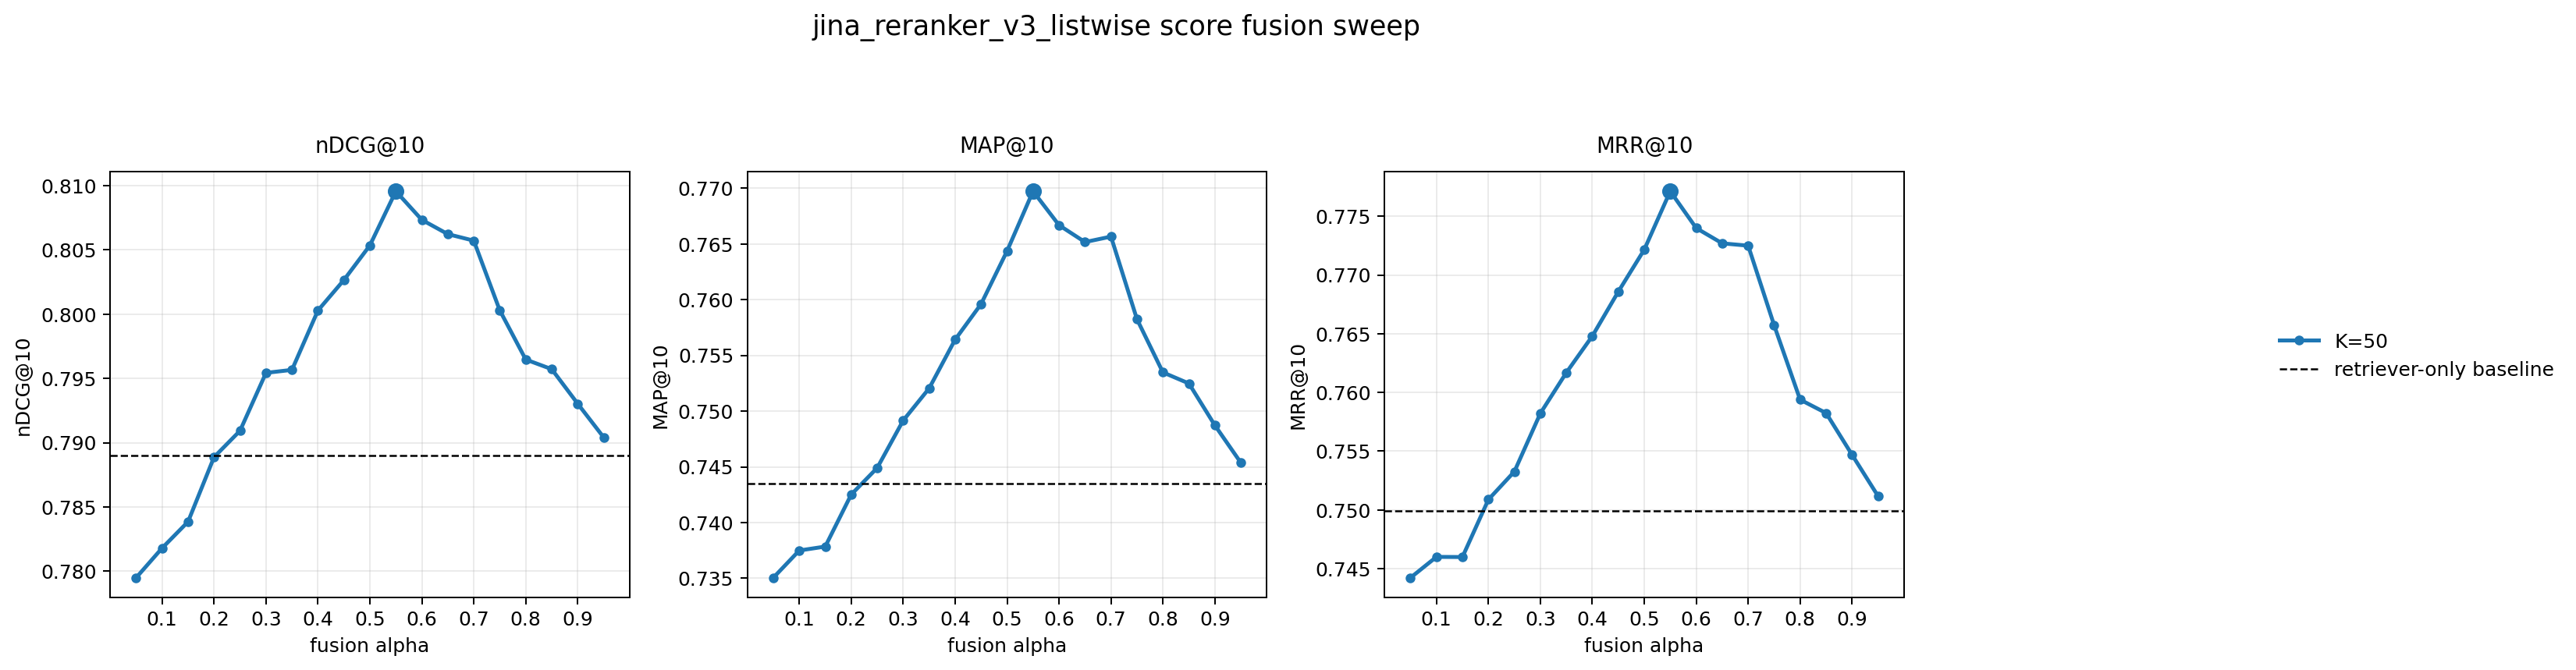

(             stage            retriever_model  \
 0     score_fusion  embeddinggemma_fact_check   
 1     score_fusion  embeddinggemma_fact_check   
 2     score_fusion  embeddinggemma_fact_check   
 3     score_fusion  embeddinggemma_fact_check   
 4     score_fusion  embeddinggemma_fact_check   
 5     score_fusion  embeddinggemma_fact_check   
 6     score_fusion  embeddinggemma_fact_check   
 7     score_fusion  embeddinggemma_fact_check   
 8     score_fusion  embeddinggemma_fact_check   
 9     score_fusion  embeddinggemma_fact_check   
 10    score_fusion  embeddinggemma_fact_check   
 11    score_fusion  embeddinggemma_fact_check   
 12    score_fusion  embeddinggemma_fact_check   
 13    score_fusion  embeddinggemma_fact_check   
 14    score_fusion  embeddinggemma_fact_check   
 15  retriever_only  embeddinggemma_fact_check   
 16    score_fusion  embeddinggemma_fact_check   
 17    score_fusion  embeddinggemma_fact_check   
 18    score_fusion  embeddinggemma_fact_check   


In [27]:
from IPython.display import Markdown, display

display(Markdown((JINA_V3_OUTPUT_DIR / "REPORT.md").read_text()))
render_alpha_sweep_plots(
    summary_path=JINA_V3_FUSION_OUTPUT_DIR / "summary.csv",
    plots_dir=JINA_V3_FUSION_OUTPUT_DIR / "alpha_plots",
    title_suffix=f"{JINA_V3_LABEL} score fusion sweep",
    show_report_path=JINA_V3_FUSION_OUTPUT_DIR / "REPORT.md",
)


In [ ]:
# Inspect a specific reranker log after a failure.
RERANKER_TO_INSPECT = RERANKERS[0]
log_path = OUTPUT_DIR / RERANKER_TO_INSPECT / "run.log"
if log_path.exists():
    print(log_path.read_text()[-8000:])
else:
    print(f"No log found at {log_path}")


In [ ]:
# Optional: rerun a single reranker with a smaller batch size.
# Example:
# RERANKER_BATCH_OVERRIDES['qwen3_reranker_0_6b'] = 4
# single_result = run_one_reranker('qwen3_reranker_0_6b')
# single_result


In [15]:
# Optional: zip the aggregate directory for download from Colab.
!zip -r "colab_scifact_rerank_20260430_183744.zip" benchmarks/scifact/results/colab_scifact_rerank_20260430_183744


  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/ (stored 0%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/summary.csv (deflated 67%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen3_reranker_0_6b/ (stored 0%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen3_reranker_0_6b/run.log (deflated 71%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen3_reranker_0_6b/summary.csv (deflated 62%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen3_reranker_0_6b/plots/ (stored 0%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen3_reranker_0_6b/plots/avg_total_query_latency_ms.png (deflated 23%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen3_reranker_0_6b/plots/ndcg_at_10.png (deflated 25%)
  adding: benchmarks/scifact/results/colab_scifact_rerank_20260430_183744/qwen

In [16]:
%pwd

'/content/ScholarRAG'